## 3.1 Contents<a id='3.1_Contents'></a>
* [3 Exploratory Data Analysis](#3_Exploratory_Data_Analysis)
  * [3.1 Contents](#3.1_Contents)
  * [3.2 Introduction](#3.2_Introduction)
  * [3.3 Imports](#3.3_Imports)
  * [3.4 Load The Data](#3.4_Load_The_Data)
    * [3.4.1 CO2 Country Year data](#3.4.1_CO2_Country_Year_data)
    * [3.4.2 CO2 Plastics Global data](#3.4.2_CO2_Plastics_Global_data)
  * [3.5 Explore The Data](#3.5_Explore_The_Data)
    * [3.5.1 Global CO2 Plastics Data Analysis](#3.5.1_Global_CO2_Plastics_Data_Analysis)
      * [3.5.1.1 Trends Analysis](#3.5.1.1_Trends_Analysis)
      * [3.5.1.2 Correlation_Analysis](#3.5.1.2_Correlation_Analysis)
      * [3.5.1.3 First Difference Analysis](#3.5.1.3_First_Difference_Analysis)
      * [3.5.1.4 Decoupling Analysis](#3.5.1.4_Decoupling_Analysis)
      * [3.5.1.5 Lag Analysis](#3.5.1.5_Lag_Analysis)
      * [3.5.1.6 Multicollinearity Check](#3.5.1.6_Multicollinearity_Check)
    * [3.5.2 CO2 Country Year Data Analysis](#3.5.2_CO2_Country_Year_Data_Analysis)
      * [3.5.2.1 Dataset Overview](#3.5.2.1_Dataset_Overview)
      * [3.5.2.2 Distributions Analysis](#3.5.2.2_Distributions_Analysis)
      * [3.5.2.3 Trends Analysis](#3.5.2.3_Trends_Analysis)
      * [3.5.2.4 Decoupling Analysis](#3.5.2.4_Decoupling_Analysis)
      * [3.5.2.5 Feature Relationships](#3.5.2.5_Feature_Relationships)
      * [3.5.2.6 Multicollinearity Check](#3.5.2.6_Multicollinearity_Check)
      * [3.5.2.7 Model Readiness Checks](#3.5.2.7_Model_Readiness_Checks)
  * [3.6 Summary](#3.6_Summary)

## 3.2 Introduction<a id='3.2_Introduction'></a>

The core problem we are trying to model for is global warming within the context of global plastic production in the last few decades using carbon di oxide emission levels as our key indicator. The co2 master data we started with in the previous step of data wrangling contained multiple co2 emission columns along with a host of potential features to predict co2 emissions at the country year level. We decided to proceed with population, gdp and energy per capita as our key independent features and co2 emissions column as the dependent variable. We also decided to use co2 per capita, co2 per gdp and energy per gdp columns for exploratory data analysis. We cleaned the dataset to exclude rows with regions that did not represent a country (ex. continents) and missing co2 info.

We also created a global co2 + plastics production dataset at global year level by merging the global year plastic production data with our co2 master data from above. We plan to use this to see how global plastic production and other macroeconomic factors correlate with yearly co2 emissions.

Both our datasets span the time period from 1990 to 2019 since that subset has the most complete picture with least amount of missing data.

Next, we will import the needed python packages and load both our cleaned datasets mentioned above and begin exploring them.

## 3.3 Imports<a id='3.3_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from library.sb_utils import save_file

## 3.4 Load The Data<a id='3.4_Load_The_Data'></a>

### 3.4.1 CO2 Master data<a id='3.4.1_CO2_Master_data'></a>

In [2]:
co2_data = pd.read_csv('../data/processed/co2_data_cleaned.csv')

In [3]:
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            4920 non-null   object 
 1   year               4920 non-null   int64  
 2   iso_code           4920 non-null   object 
 3   population         4920 non-null   float64
 4   gdp                4918 non-null   float64
 5   co2                4919 non-null   float64
 6   co2_per_capita     4919 non-null   float64
 7   co2_per_gdp        4917 non-null   float64
 8   energy_per_capita  4869 non-null   float64
 9   energy_per_gdp     4867 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 384.5+ KB


In [4]:
co2_data.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp
0,Afghanistan,1990,AFG,12045664.0,1.306598e+10,2.024,0.168,0.155,2506.867,2.311
1,Afghanistan,1991,AFG,12238879.0,1.204736e+10,1.914,0.156,0.159,1021.075,1.037
2,Afghanistan,1992,AFG,13278983.0,1.267754e+10,1.482,0.112,0.117,618.055,0.647
3,Afghanistan,1993,AFG,14943175.0,9.834582e+09,1.487,0.100,0.151,545.758,0.829
4,Afghanistan,1994,AFG,16250800.0,7.919856e+09,1.454,0.089,0.184,484.346,0.994


In [5]:
co2_data.describe()

,year,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp
count,4920.000000,4.920000e+03,4.918000e+03,4919.000000,4919.000000,4917.000000,4869.000000,4867.000000
mean,2004.500000,3.954455e+07,4.620885e+11,172.782212,5.007164,0.357906,25410.944986,1.579217
std,8.656321,1.390075e+08,1.576232e+12,717.220566,8.548931,1.220326,36169.462609,1.512807
min,1990.000000,6.790100e+04,2.571720e+08,0.044000,0.021000,0.020000,96.152000,0.078000
25%,1997.000000,3.573031e+06,1.792250e+10,3.239500,0.586000,0.153000,2512.531000,0.752000
50%,2004.500000,9.405323e+06,5.714414e+10,17.322000,2.591000,0.249000,11297.704000,1.198000
75%,2012.000000,2.643409e+07,2.790671e+11,79.189500,6.938000,0.402000,34099.367000,1.927000
max,2019.000000,1.423520e+09,2.363194e+13,10713.515000,364.791000,82.599000,318559.688000,23.021000


### 3.4.2 Global CO2 Plastics data<a id='3.4.2_Global_CO2_Plastics_data'></a>

In [6]:
global_co2_plastics_data = pd.read_csv('../data/processed/co2_plastics_global_data_cleaned.csv')

In [7]:
global_co2_plastics_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   year                                     30 non-null     int64  
 1   total_co2_mt                             30 non-null     float64
 2   population_global_millions               30 non-null     float64
 3   gdp_global_trillions                     30 non-null     float64
 4   co2_per_capita_global                    30 non-null     float64
 5   energy_per_capita_global                 30 non-null     float64
 6   co2_per_gdp_global                       30 non-null     float64
 7   energy_per_gdp_global                    30 non-null     float64
 8   Region                                   30 non-null     object 
 9   Code                                     30 non-null     object 
 10  Total_Plastic_Production_Million_Tonnes  30 non-null

In [8]:
global_co2_plastics_data.head()

,year,total_co2_mt,population_global_millions,gdp_global_trillions,co2_per_capita_global,energy_per_capita_global,co2_per_gdp_global,energy_per_gdp_global,Region,Code,Total_Plastic_Production_Million_Tonnes
0,1990,22151.752,5273.165997,43.043695,4.200857,17913.731123,0.514668,2.194477,World,OWID_WRL,120.0
1,1991,22629.544,5363.585230,43.723968,4.219073,17751.749871,0.516162,2.167922,World,OWID_WRL,124.0
2,1992,21934.868,5450.407014,44.739481,4.024572,17670.623494,0.488954,2.143788,World,OWID_WRL,132.0
3,1993,22160.568,5534.809580,45.909800,4.003781,17550.179060,0.482686,2.115912,World,OWID_WRL,137.0
4,1994,22356.106,5617.332056,47.530495,3.979900,17516.992426,0.470337,2.070229,World,OWID_WRL,151.0


In [9]:
global_co2_plastics_data.describe()

,year,total_co2_mt,population_global_millions,gdp_global_trillions,co2_per_capita_global,energy_per_capita_global,co2_per_gdp_global,energy_per_gdp_global,Total_Plastic_Production_Million_Tonnes
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2004.500000,28330.523300,6485.306052,75.751702,4.340778,19147.982938,0.393900,1.734743,264.030121
std,8.803408,4938.690543,736.784039,25.092666,0.289952,1333.705999,0.064485,0.268066,99.803769
min,1990.000000,21934.868000,5273.165997,43.043695,3.956980,17516.992426,0.292347,1.329800,120.000000
25%,1997.250000,23557.049500,5882.395168,53.903100,4.035194,17845.726626,0.350919,1.517699,182.000000
50%,2004.500000,28125.556000,6470.266999,71.840092,4.346636,19296.196422,0.391592,1.738357,259.500000
75%,2011.750000,33668.064500,7089.745618,95.941934,4.624710,20517.651415,0.438127,1.942222,334.750000
max,2019.000000,35763.443000,7707.707472,122.266915,4.751147,21092.058557,0.516162,2.194477,459.746016


## 3.5 Explore The Data<a id='3.5_Explore_The_Data'></a>

We can break down CO2 emissions as follows
CO2 = Population × (GDP / Population) × (Energy / GDP) × (CO2 / Energy)

So, we will be focusing on these independent variables like GDP, Energy per Capita, Population in addition to Plastics to look at how they affect CO2 emissions.

### 3.5.1 Global CO2 Plastics Data Analysis<a id='3.5.1_Global_CO2_Plastics_Data_Analysis'></a>

#### 3.5.1.1 Trends Analysis<a id='3.5.1.1_Trends_Analysis'></a>

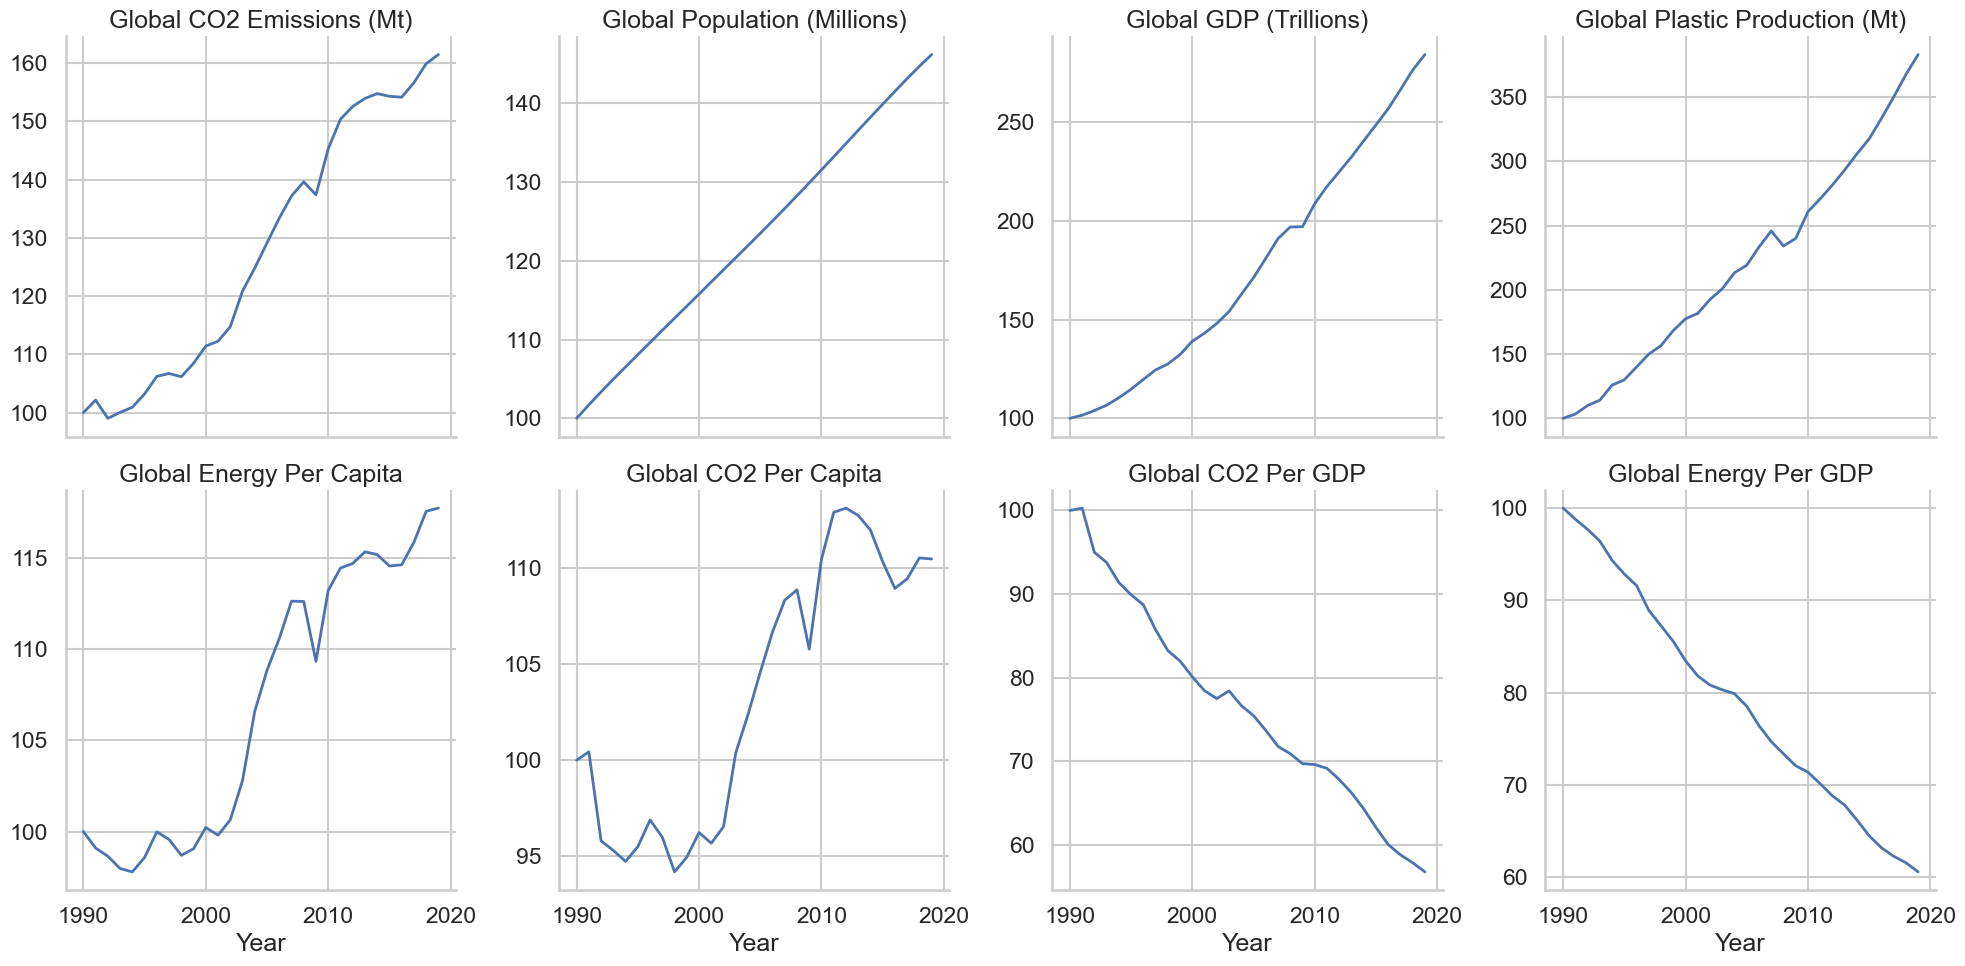

In [10]:
#global normalized feature trends over the past 30 years (normalized all features to index = 100 in the starting year)
sns.set_theme(style="whitegrid", context="talk")
features = ["total_co2_mt", "population_global_millions", "gdp_global_trillions", "Total_Plastic_Production_Million_Tonnes", 
            "energy_per_capita_global", "co2_per_capita_global", "co2_per_gdp_global","energy_per_gdp_global"]
global_co2_plastics_norm = global_co2_plastics_data.copy()
for f in features:
    global_co2_plastics_norm[f] = (global_co2_plastics_norm[f]/global_co2_plastics_norm[f].iloc[0])*100
    
global_co2_plastics_data_long = global_co2_plastics_norm.melt(id_vars="year", value_vars=features, var_name="metric", value_name="value")
labels_dict = {"total_co2_mt" : "Global CO2 Emissions (Mt)", 
               "population_global_millions" : "Global Population (Millions)", 
               "gdp_global_trillions" : "Global GDP (Trillions)", 
               "Total_Plastic_Production_Million_Tonnes" : "Global Plastic Production (Mt)", 
               "energy_per_capita_global" : "Global Energy Per Capita", 
               "co2_per_capita_global" : "Global CO2 Per Capita", 
               "co2_per_gdp_global" : "Global CO2 Per GDP",
               "energy_per_gdp_global" : "Global Energy Per GDP"}
global_co2_plastics_data_long["metric"] = global_co2_plastics_data_long["metric"].map(labels_dict)
gd = sns.FacetGrid(global_co2_plastics_data_long, col="metric", col_wrap=4, sharex = True, sharey = False, height = 5)
gd.map_dataframe(sns.lineplot, x = "year", y = "value", linewidth = 2)

gd.set_titles("{col_name}")
gd.set_axis_labels("Year","")
plt.tight_layout()
plt.show()

We can see that all our core features of Global CO2 Emissions, Population, GDP, Energy Use Per Capita and Plastic Production have been consistently increasing over the past 3 decades from 1990 to 2019. While we see Global CO2 Per GDP and Global Energy Per GDP decreasing consistently over the same time period indicating gains in energy efficiency and some decoupling of economic activity from total emissions, the increasing CO2 trend tells us that the efficiency gains have not been enough to offset the scale of economic growth and CO2 emissions.

When looking at different decades, 1990–2000, 2000–2010, 2010–2019
We see higher plastic production growth rate post-2010.
We also see growth rate slow down for Total CO2 emissions, Global Energy Per Capita and Global CO2 per capita when comparing 2000-2010 time period to post 2010.

#### 3.5.1.2 Correlation Analysis<a id='3.5.1.2_Correlation_Analysis'></a>

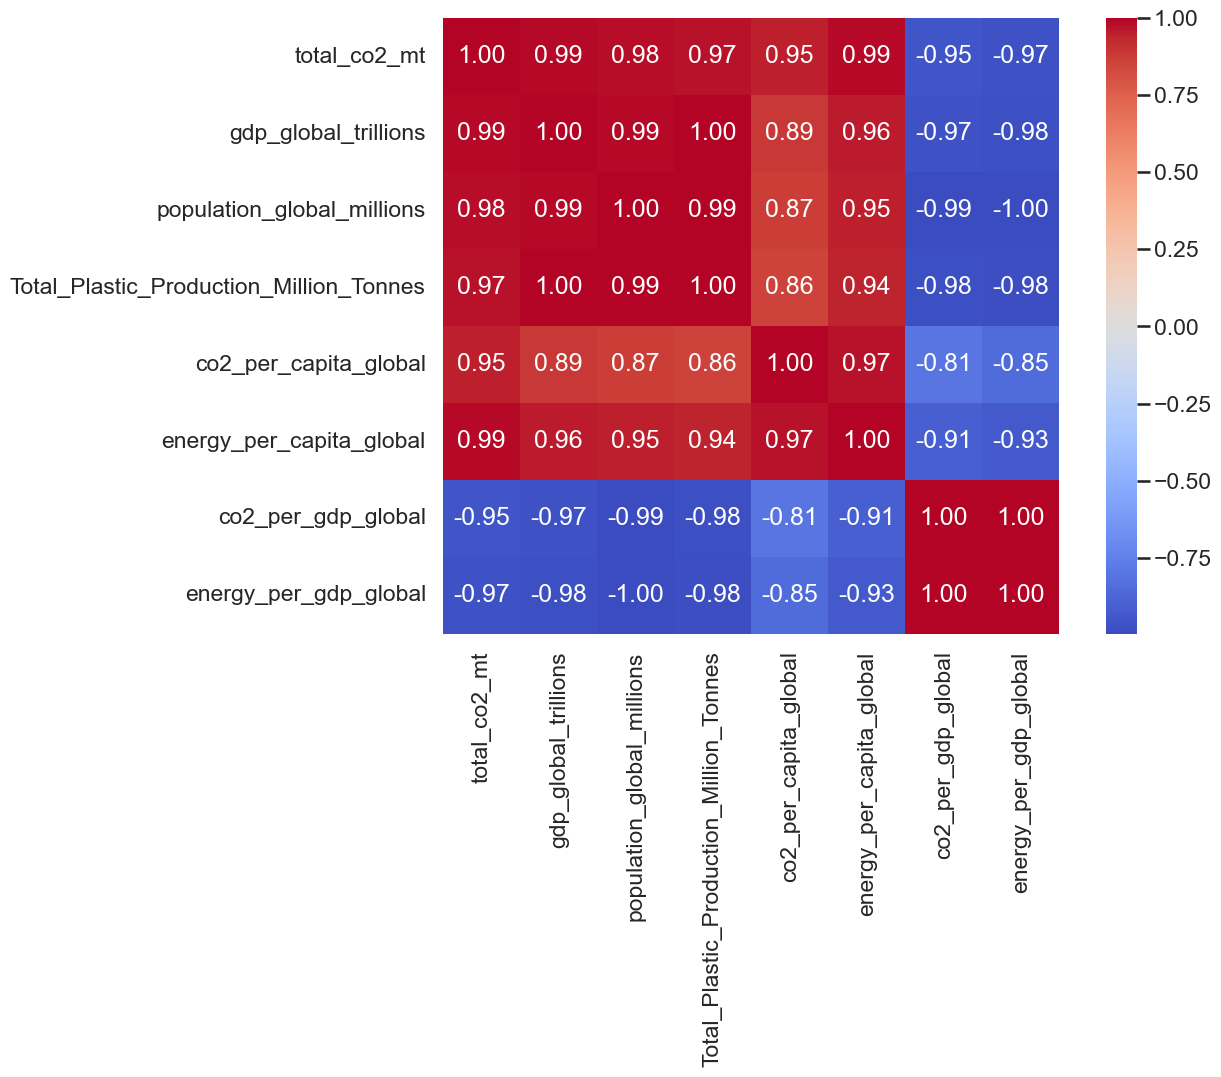

In [11]:
#Show a seaborn heatmap of correlations in global co2 + plastics dataset
features = ["total_co2_mt",
    "gdp_global_trillions",
    "population_global_millions",
    "Total_Plastic_Production_Million_Tonnes",
    "co2_per_capita_global",
    "energy_per_capita_global",
    "co2_per_gdp_global",
    "energy_per_gdp_global"]
global_co2_plastics_subset = global_co2_plastics_data[features]
plt.subplots(figsize=(12,8))
sns.heatmap(global_co2_plastics_subset.corr(), annot = True, cmap = "coolwarm", fmt = ".2f", square = True);

From the quick correlation analysis above, we see strong positive correlations between global CO2 emissions & GDP, Population, Total Plastic Production and Energy Per Capita. This indicates that as GDP, Population, Total Plastic Production increase globally, total CO2 emissions also increase. We also see strong negative correlations of all of the above stated variables with co2_per_gdp_global and energy_per_gdp_global. This is the same effect we observed earlier in our line plots where even though energy efficiency gains have happened over the past serveral decades they have not been enough to offset the scale of economic growth and CO2 emissions.

It is important to investigate these strong positive correlations further to understand the relationships between these variables better. We will do another correlation matrix for growth rates for this

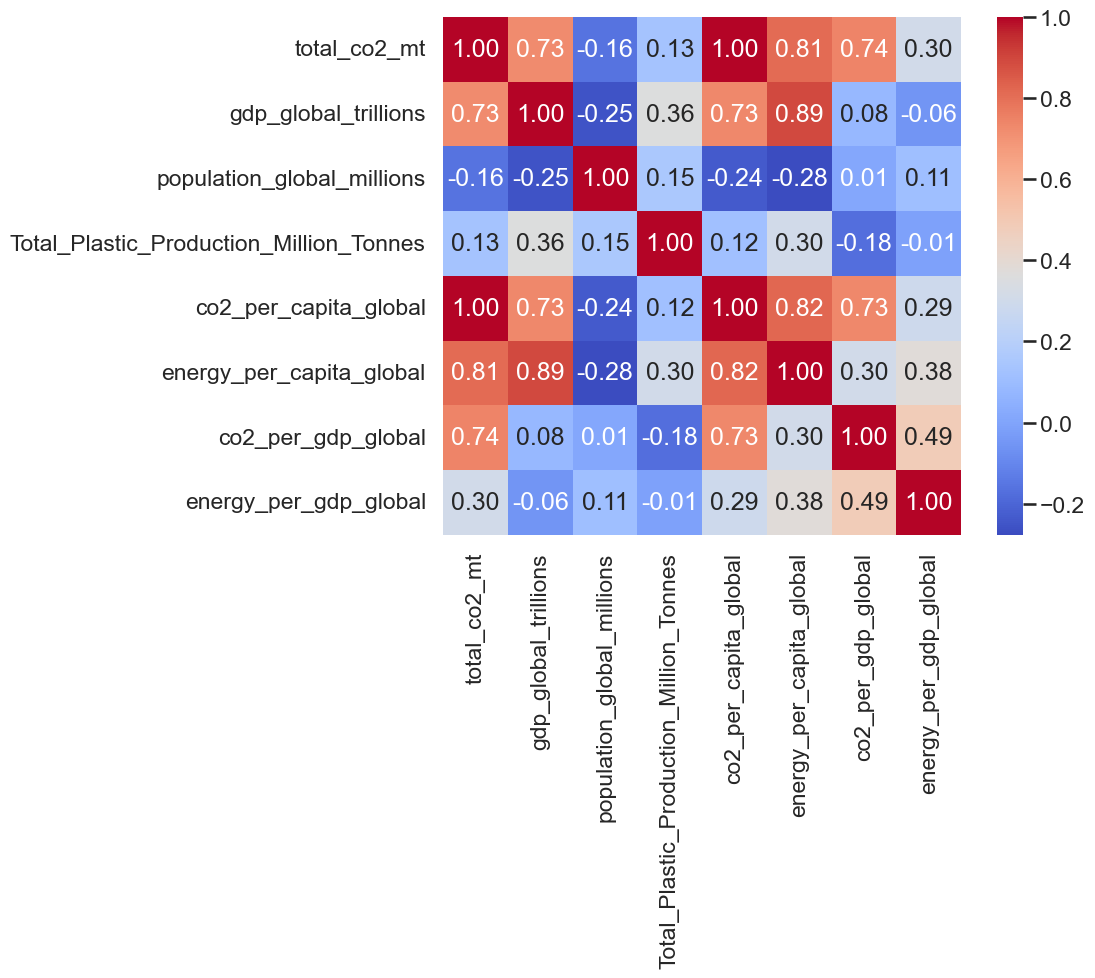

In [12]:
#correlations for growth rates
global_co2_plastics_growth= global_co2_plastics_data[features].pct_change().dropna()
plt.subplots(figsize=(12,10))
sns.heatmap(global_co2_plastics_growth.corr(), annot = True, cmap = "coolwarm", fmt = ".2f", square = True);
plt.tight_layout()
plt.show()

We see the strength of correlations decline based on the percent growth matrix above. This tells us that strong correlations we observed in the first raw correlation matrix are due to the consistent upward trends for all variables for the past several decades (comovement) and not due to causation. It would be good to explore our co2 country year dataset to better understand the relationship between these variables.

Let us assess the correlation of these variables with our target/dependent variable CO2 emissions only.

In [13]:
print(global_co2_plastics_growth.corr()['total_co2_mt'].sort_values(ascending=False))

total_co2_mt                               1.000000
co2_per_capita_global                      0.997032
energy_per_capita_global                   0.811885
co2_per_gdp_global                         0.744387
gdp_global_trillions                       0.725470
energy_per_gdp_global                      0.302290
Total_Plastic_Production_Million_Tonnes    0.128464
population_global_millions                -0.161238
Name: total_co2_mt, dtype: float64


The only strong correlation of CO2 emissions percent growth year over year is with energy per capita which makes sense since energy consumption increase leads to increased CO2 emissions. We also see a moderate positive correlation with global gdp growth i.e increase in economic activity year over year is correlated with increase in CO2 emissions year over year.

#### 3.5.1.3 First Difference Analysis<a id='3.5.1.3_First_Difference_Analysis'></a>

Next, we will further investigate the impact of independent variables like GDP, Population, Plastics etc. on our target variable CO2 by doing first difference analysis. This means we will try to understand CO2 delta over time as a function of these independent variables' delta over time.

In [14]:
#First Difference Analysis using our dataset
global_co2_plastics_fd = global_co2_plastics_data.copy()
fd_cols = ["total_co2_mt",
    "gdp_global_trillions",
    "population_global_millions",
    "Total_Plastic_Production_Million_Tonnes",
    "energy_per_capita_global"]
for col in fd_cols:
    global_co2_plastics_fd[f"d_{col}"]=global_co2_plastics_fd[col].diff()
global_co2_plastics_fd_diff = global_co2_plastics_fd.dropna().copy()   

In [15]:
#Correlation with deltas
global_co2_plastics_fd_corr_diff = global_co2_plastics_fd_diff[
    [f"d_{col}" for col in fd_cols]
].corr()["d_total_co2_mt"].sort_values(ascending=False)
print(global_co2_plastics_fd_corr_diff)

d_total_co2_mt                               1.000000
d_energy_per_capita_global                   0.845330
d_gdp_global_trillions                       0.629714
d_Total_Plastic_Production_Million_Tonnes    0.252010
d_population_global_millions                -0.156875
Name: d_total_co2_mt, dtype: float64


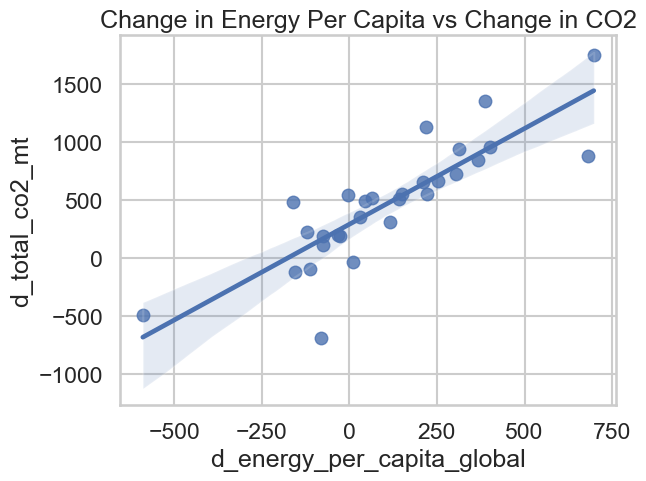

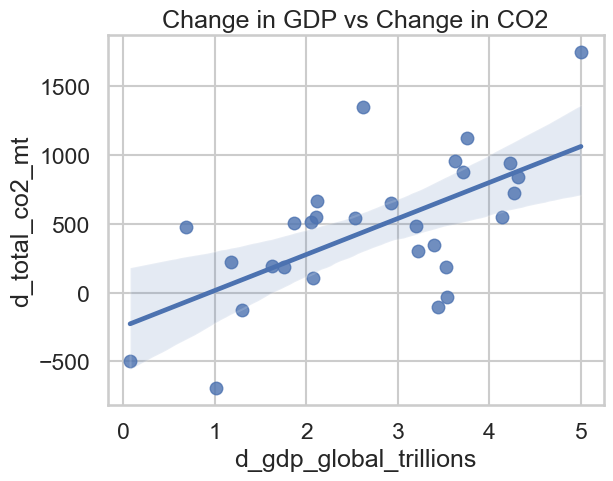

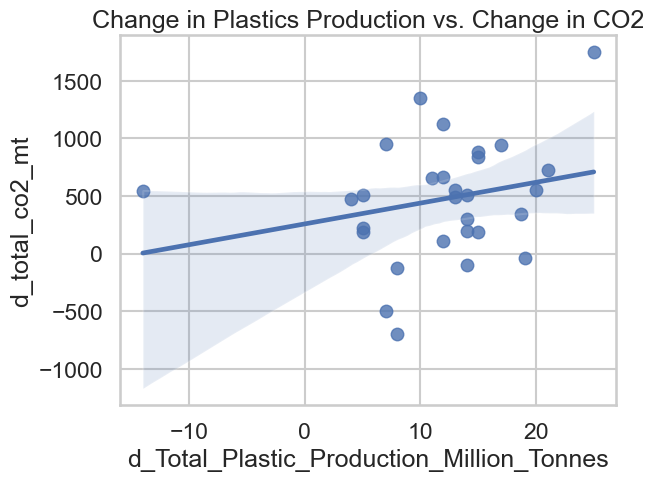

In [16]:
#Lineplots for delta relationships
#Energy Per Capita Vs. CO2 Delta over time
sns.regplot(
    data=global_co2_plastics_fd_diff,
    x="d_energy_per_capita_global",
    y="d_total_co2_mt",
)
plt.title("Change in Energy Per Capita vs Change in CO2")
plt.show()

#GDP Vs. CO2 Delta over time
sns.regplot(
    data=global_co2_plastics_fd_diff,
    x="d_gdp_global_trillions",
    y="d_total_co2_mt",
)
plt.title("Change in GDP vs Change in CO2")
plt.show()

#Plastic Vs. CO2 Delta over time
sns.regplot(
    data=global_co2_plastics_fd_diff,
    x="d_Total_Plastic_Production_Million_Tonnes",
    y="d_total_co2_mt",
)
plt.title("Change in Plastics Production vs. Change in CO2")
plt.show()

We see strong relationship between CO2 change over time with Energy per Capita change over time. We also see a moderate relationship between CO2 and GDP delta over time. There is a weaker relationship between CO2 emissions delta and Plastic production delta over time.

#### 3.5.1.4 Decoupling Analysis<a id='3.5.1.4_Decoupling_Analysis'></a>

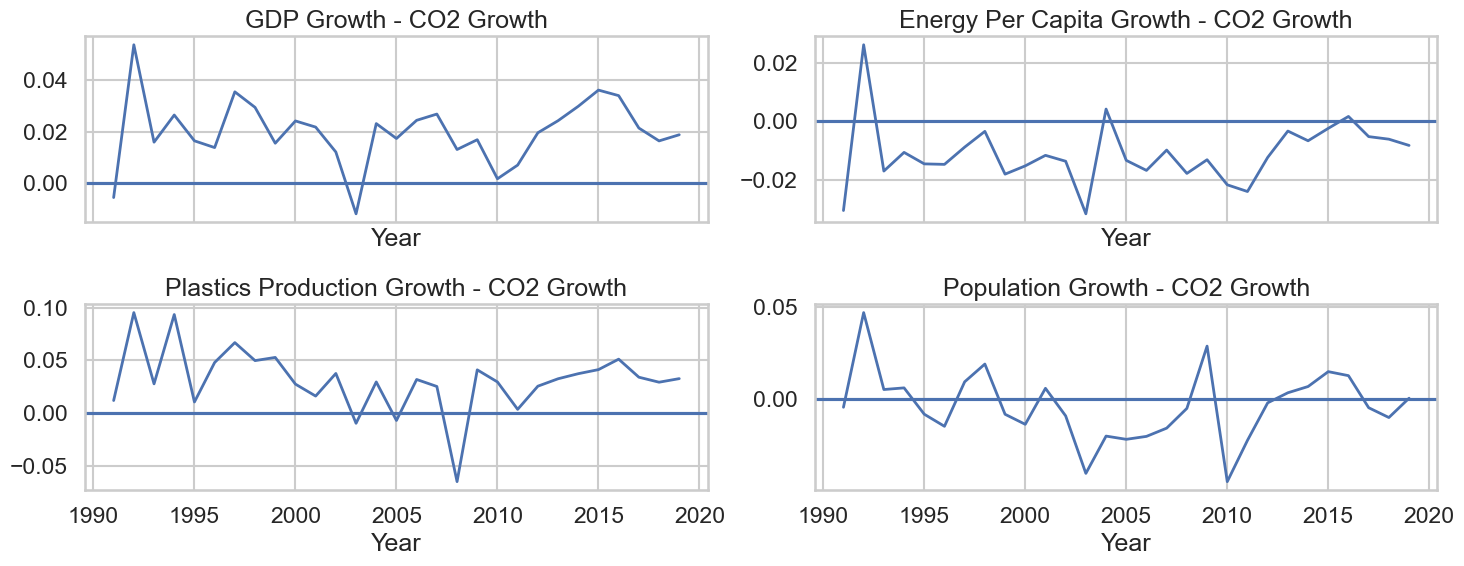

In [17]:
global_co2_plastics_pct_growth = global_co2_plastics_data.set_index('year')
global_co2_plastics_pct_growth = global_co2_plastics_pct_growth[features].pct_change().dropna()
global_co2_plastics_pct_growth["decoupling_gdp_co2"] = global_co2_plastics_pct_growth["gdp_global_trillions"] - global_co2_plastics_pct_growth["total_co2_mt"]
global_co2_plastics_pct_growth["decoupling_energy_co2"] = global_co2_plastics_pct_growth["energy_per_capita_global"] - global_co2_plastics_pct_growth["total_co2_mt"]
global_co2_plastics_pct_growth["decoupling_plastic_co2"] = global_co2_plastics_pct_growth["Total_Plastic_Production_Million_Tonnes"] - global_co2_plastics_pct_growth["total_co2_mt"]
global_co2_plastics_pct_growth["decoupling_population_co2"] = global_co2_plastics_pct_growth["population_global_millions"] - global_co2_plastics_pct_growth["total_co2_mt"]
fig, axes = plt.subplots(2,2, figsize=(15,6), sharex = True)
axes[0,0].plot(global_co2_plastics_pct_growth.index, global_co2_plastics_pct_growth["decoupling_gdp_co2"],linewidth = 2)
axes[0,0].axhline(0)
axes[0,0].set_title("GDP Growth - CO2 Growth")
axes[0,0].set_xlabel("Year")
axes[0,1].plot(global_co2_plastics_pct_growth.index, global_co2_plastics_pct_growth["decoupling_energy_co2"],linewidth = 2)
axes[0,1].axhline(0)
axes[0,1].set_title("Energy Per Capita Growth - CO2 Growth")
axes[0,1].set_xlabel("Year")
axes[1,0].plot(global_co2_plastics_pct_growth.index, global_co2_plastics_pct_growth["decoupling_plastic_co2"],linewidth = 2)
axes[1,0].axhline(0)
axes[1,0].set_title("Plastics Production Growth - CO2 Growth")
axes[1,0].set_xlabel("Year")
axes[1,1].plot(global_co2_plastics_pct_growth.index, global_co2_plastics_pct_growth["decoupling_population_co2"],linewidth = 2)
axes[1,1].axhline(0)
axes[1,1].set_title("Population Growth - CO2 Growth")
axes[1,1].set_xlabel("Year")
plt.tight_layout()
plt.show()

We can see that for most part GDP and Plastic Production grow faster than CO2 suggesting they are relatively decoupled i.e. a weaker correlation exists between them. On the other hand, Energy Per Capita grows slower than CO2 for majority of the time period suggesting stronger coupling with CO2 emissions i.e. they re more tightly correlated. However the coupling seems to have weakened in the past decade (2013 to 2019). Population Growth seems to be a weaker driver of CO2 emissions growth, although we do see some volatility throughout the time period.

#### 3.5.1.5 Lag Analysis<a id='3.5.1.4_Lag_Analysis'></a>

For this analysis, we will test if GDP, Energy Per Capita, Plastic Production and Population impact CO2 emissions immediately or with a lag.

In [18]:
lg = global_co2_plastics_data.copy()
lg["gdp_lag1"] = lg["gdp_global_trillions"].shift(1)
lg["gdp_lag2"] = lg["gdp_global_trillions"].shift(2)
lg["energy_lag1"] = lg["energy_per_capita_global"].shift(1)
lg["energy_lag2"] = lg["energy_per_capita_global"].shift(2)
lg["plastics_lag1"] = lg["Total_Plastic_Production_Million_Tonnes"].shift(1)
lg["plastics_lag2"] = lg["Total_Plastic_Production_Million_Tonnes"].shift(2)

lg_corr = lg[[
    "total_co2_mt",
    "gdp_global_trillions",
    "gdp_lag1",
    "gdp_lag2",
    "energy_per_capita_global",
    "energy_lag1",
    "energy_lag2",
    "Total_Plastic_Production_Million_Tonnes",
    "plastics_lag1",
    "plastics_lag2"
]].corr()["total_co2_mt"]

print(lg_corr)

total_co2_mt                               1.000000
gdp_global_trillions                       0.986087
gdp_lag1                                   0.982693
gdp_lag2                                   0.979257
energy_per_capita_global                   0.986349
energy_lag1                                0.976526
energy_lag2                                0.960137
Total_Plastic_Production_Million_Tonnes    0.973907
plastics_lag1                              0.975581
plastics_lag2                              0.975366
Name: total_co2_mt, dtype: float64


We see that gdp and energy per capita changes impact co2 emissions in the same year while plastic production changes show a lag in impact of 1 to 2 years.

#### 3.5.1.6 Multicollinearity Check<a id='3.5.1.4_Multicollinearity_Check'></a>

As observed in the Correlation Analysis in Section 3.5.1.2, there is a lot of multicollinearity between our variables. We will do a formal check in this section by removing some of the dependent ratio features like co2/gdp etc. and see if we can consider this global data for modeling step.

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols = ["gdp_global_trillions",
        "population_global_millions",
        "Total_Plastic_Production_Million_Tonnes",
        "energy_per_capita_global"]

vif = global_co2_plastics_subset[cols].dropna()

global_co2_plastics_vif = pd.DataFrame()
global_co2_plastics_vif["feature"] = vif.columns
global_co2_plastics_vif["VIF"] = [variance_inflation_factor(vif.values, i) for i in range(len(vif.columns))]

global_co2_plastics_vif

,feature,VIF
0,gdp_global_trillions,1547.582460
1,population_global_millions,3127.492466
2,Total_Plastic_Production_Million_Tonnes,1495.549058
3,energy_per_capita_global,2511.486233


Variance Inflation Factor is extremely high suggesting severe multicollinearity among our core predictor variables. If we still need to use this data for modeling we will have to check the first difference dataset for this global data and see if that is usable.

In [20]:
#vif on first difference dataset created earlier from co2 plastics global dataset
fdcols = ["d_gdp_global_trillions",
        "d_population_global_millions",
        "d_Total_Plastic_Production_Million_Tonnes",
        "d_energy_per_capita_global"]

vif = global_co2_plastics_fd_diff[fdcols].dropna()

global_co2_plastics_fd_vif = pd.DataFrame()
global_co2_plastics_fd_vif["feature"] = vif.columns
global_co2_plastics_fd_vif["VIF"] = [variance_inflation_factor(vif.values, i)
                   for i in range(len(vif.columns))]

global_co2_plastics_fd_vif

,feature,VIF
0,d_gdp_global_trillions,18.175148
1,d_population_global_millions,10.142962
2,d_Total_Plastic_Production_Million_Tonnes,5.755570
3,d_energy_per_capita_global,2.814176


VIF values for gdp and population are still high suggesting serious multicollinearity. We will skip this dataset for modeling and explore our co2 master dataset at country year level next.

### 3.5.2 CO2 Country Year Data Analysis<a id='3.5.1_CO2_Country_Year_Data_Analysis'></a>

#### 3.5.2.1 Dataset Overview<a id='3.5.1.7_Dataset_Overview'></a>

From the beginning section after importing  CO2 master data, we already know that the data is at country/year level and spans 30 years time period similar to the global dataset from 1990-2019. In this section we will try to understand this dataset better. 

In [21]:
#Number of countries available for analysis
co2_data['country'].nunique()

164

In [22]:
#let's check if all conutries have 30 years of data
co2_data.groupby('country')['year'].nunique()

country
Afghanistan    30
Albania        30
Algeria        30
Angola         30
Argentina      30
               ..
Venezuela      30
Vietnam        30
Yemen          30
Zambia         30
Zimbabwe       30
Name: year, Length: 164, dtype: int64

We have 164 countries represented in our dataset and all of them seem to have 30 years of data.

In [23]:
co2_data[['co2','population','gdp','energy_per_capita']].skew()

co2                  9.083402
population           7.900030
gdp                  8.027764
energy_per_capita    2.830061
dtype: float64

There seems to be skewness in this dataset with most features pointing to a highly right skewed distribution since 0 represents perfectly symmetrical distribution. Let us look into this further in our distributions analysis section next.

#### 3.5.2.2 Distributions Analysis<a id='3.5.1.7_Distributions_Analysis'></a>

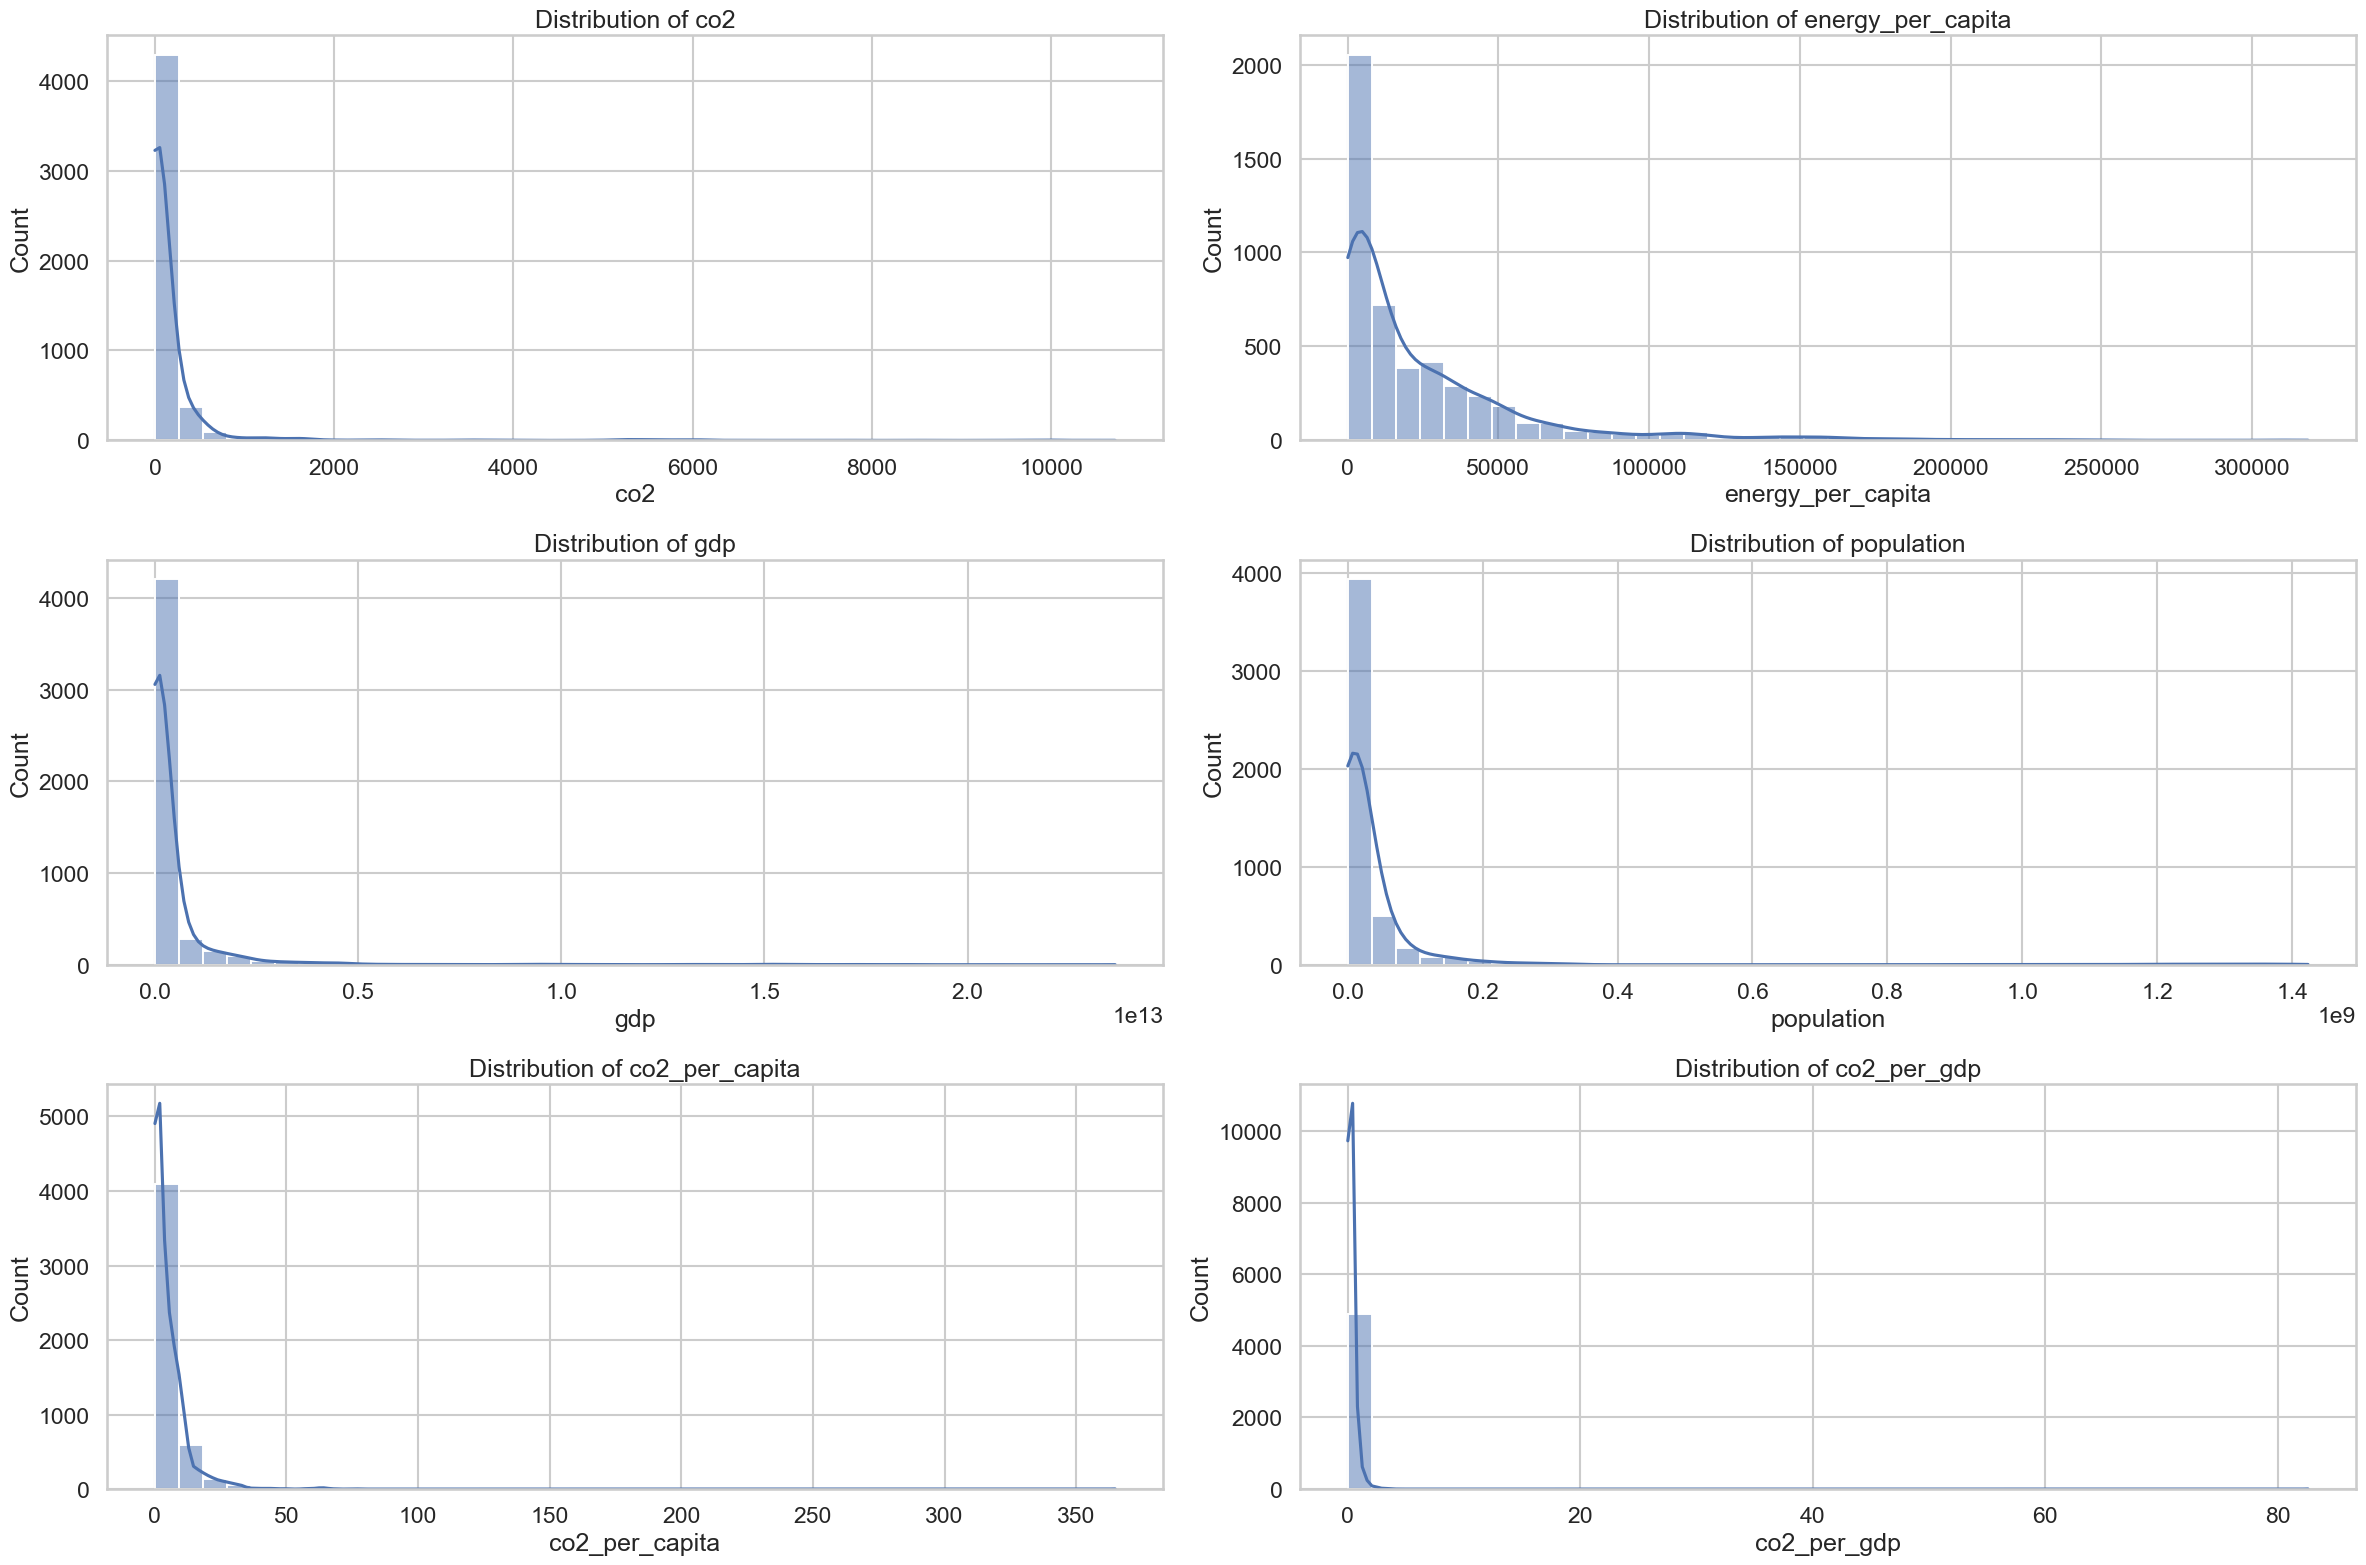

In [24]:
#Understanding distributions for key features
cols = ['co2', 'energy_per_capita', 'gdp', 'population', 'co2_per_capita','co2_per_gdp']
fig, axes = plt.subplots(3,2,figsize = (24,16))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(co2_data[col].dropna(), bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

We see all the features have right skewed distributions indicating that a few large countries/economies dominate for all these features. We may have to consider log transformations later on to reduce this effect of extreme values for these features.

Let us look at some of the outliers that seem to be dominating the core features in this dataset.

In [25]:
highest_co2_emitters = co2_data.groupby('country')['co2'].sum().sort_values(ascending=False).head(15)
highest_co2_emitters.head()

country
China            185821.780
United States    167907.598
Russia            50301.702
India             41460.135
Japan             36828.086
Name: co2, dtype: float64

China, USA, Russia, India and Japan seem to be the outliers/dominators for high core feature values in this dataset.

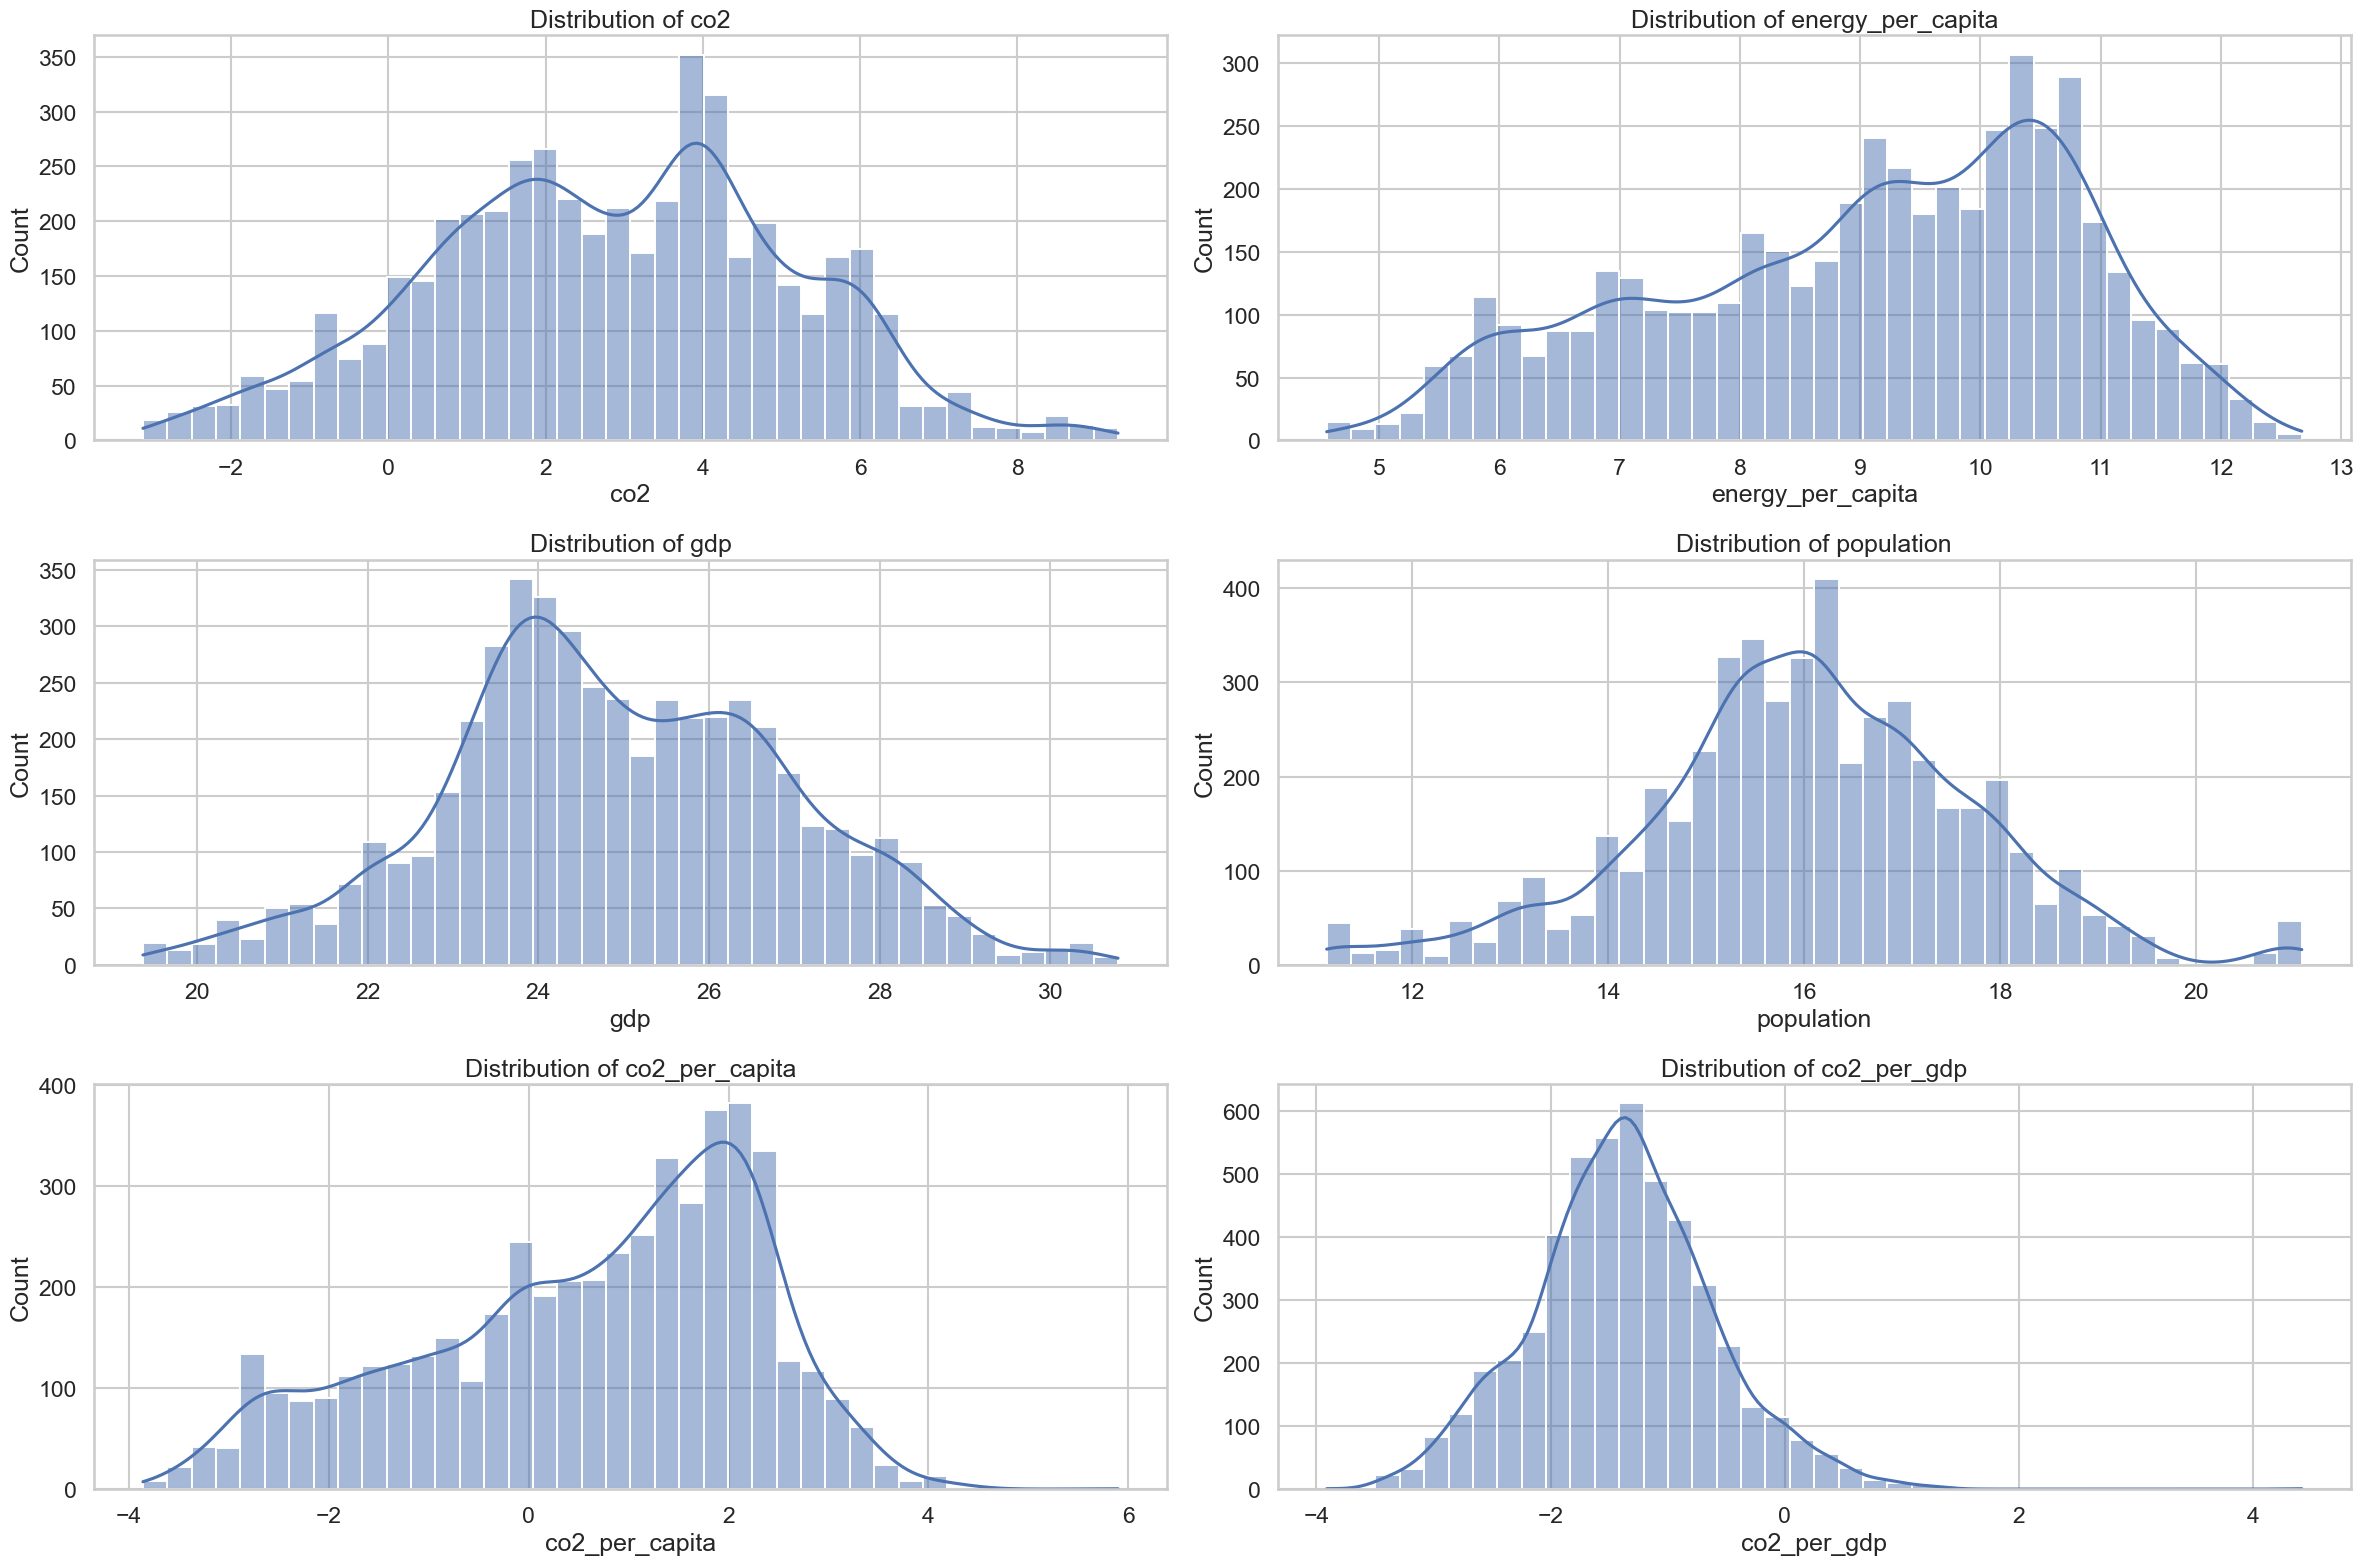

In [26]:
# lets look at the distributions after doing a log transformation on them
fig, axes = plt.subplots(3,2,figsize = (24,16))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(np.log(co2_data[col].dropna()), bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Log transformation for these features definitely reduces the skew considerably. We will potentially add columns to this dataset with log transformation of features to use for modeling later.

#### 3.5.2.3 Trends Analysis<a id='3.5.2.3_Trends_Analysis'></a>

We saw in the previous section that China,United States,Russia,India,Japan were some of the top countries with highest CO2 emissions.

Let us identify countries that have population, gdp greater than 90th quantile in the overall dataset to understand patterns in the co2 emission trends.

In [27]:
high_low_co2_emitters = co2_data[(co2_data['population'] > co2_data['population'].quantile(0.9)) & (co2_data['gdp'] > co2_data['gdp'].quantile(0.9))].groupby('country')['co2'].mean().sort_values(ascending=False)
high_low_co2_emitters.head(100)

country
China            6194.059333
United States    5596.919933
Russia           1676.723400
India            1382.004500
Japan            1227.602867
Germany           874.853433
Iran              603.351643
Mexico            449.486652
Indonesia         404.778720
Brazil            377.139233
Turkey            364.725615
Thailand          282.934800
Egypt             238.066500
Pakistan          185.588800
Nigeria           116.346167
Name: co2, dtype: float64

Lets create CO2 Line plots for these countries to visualize the trend over the past 30 years.

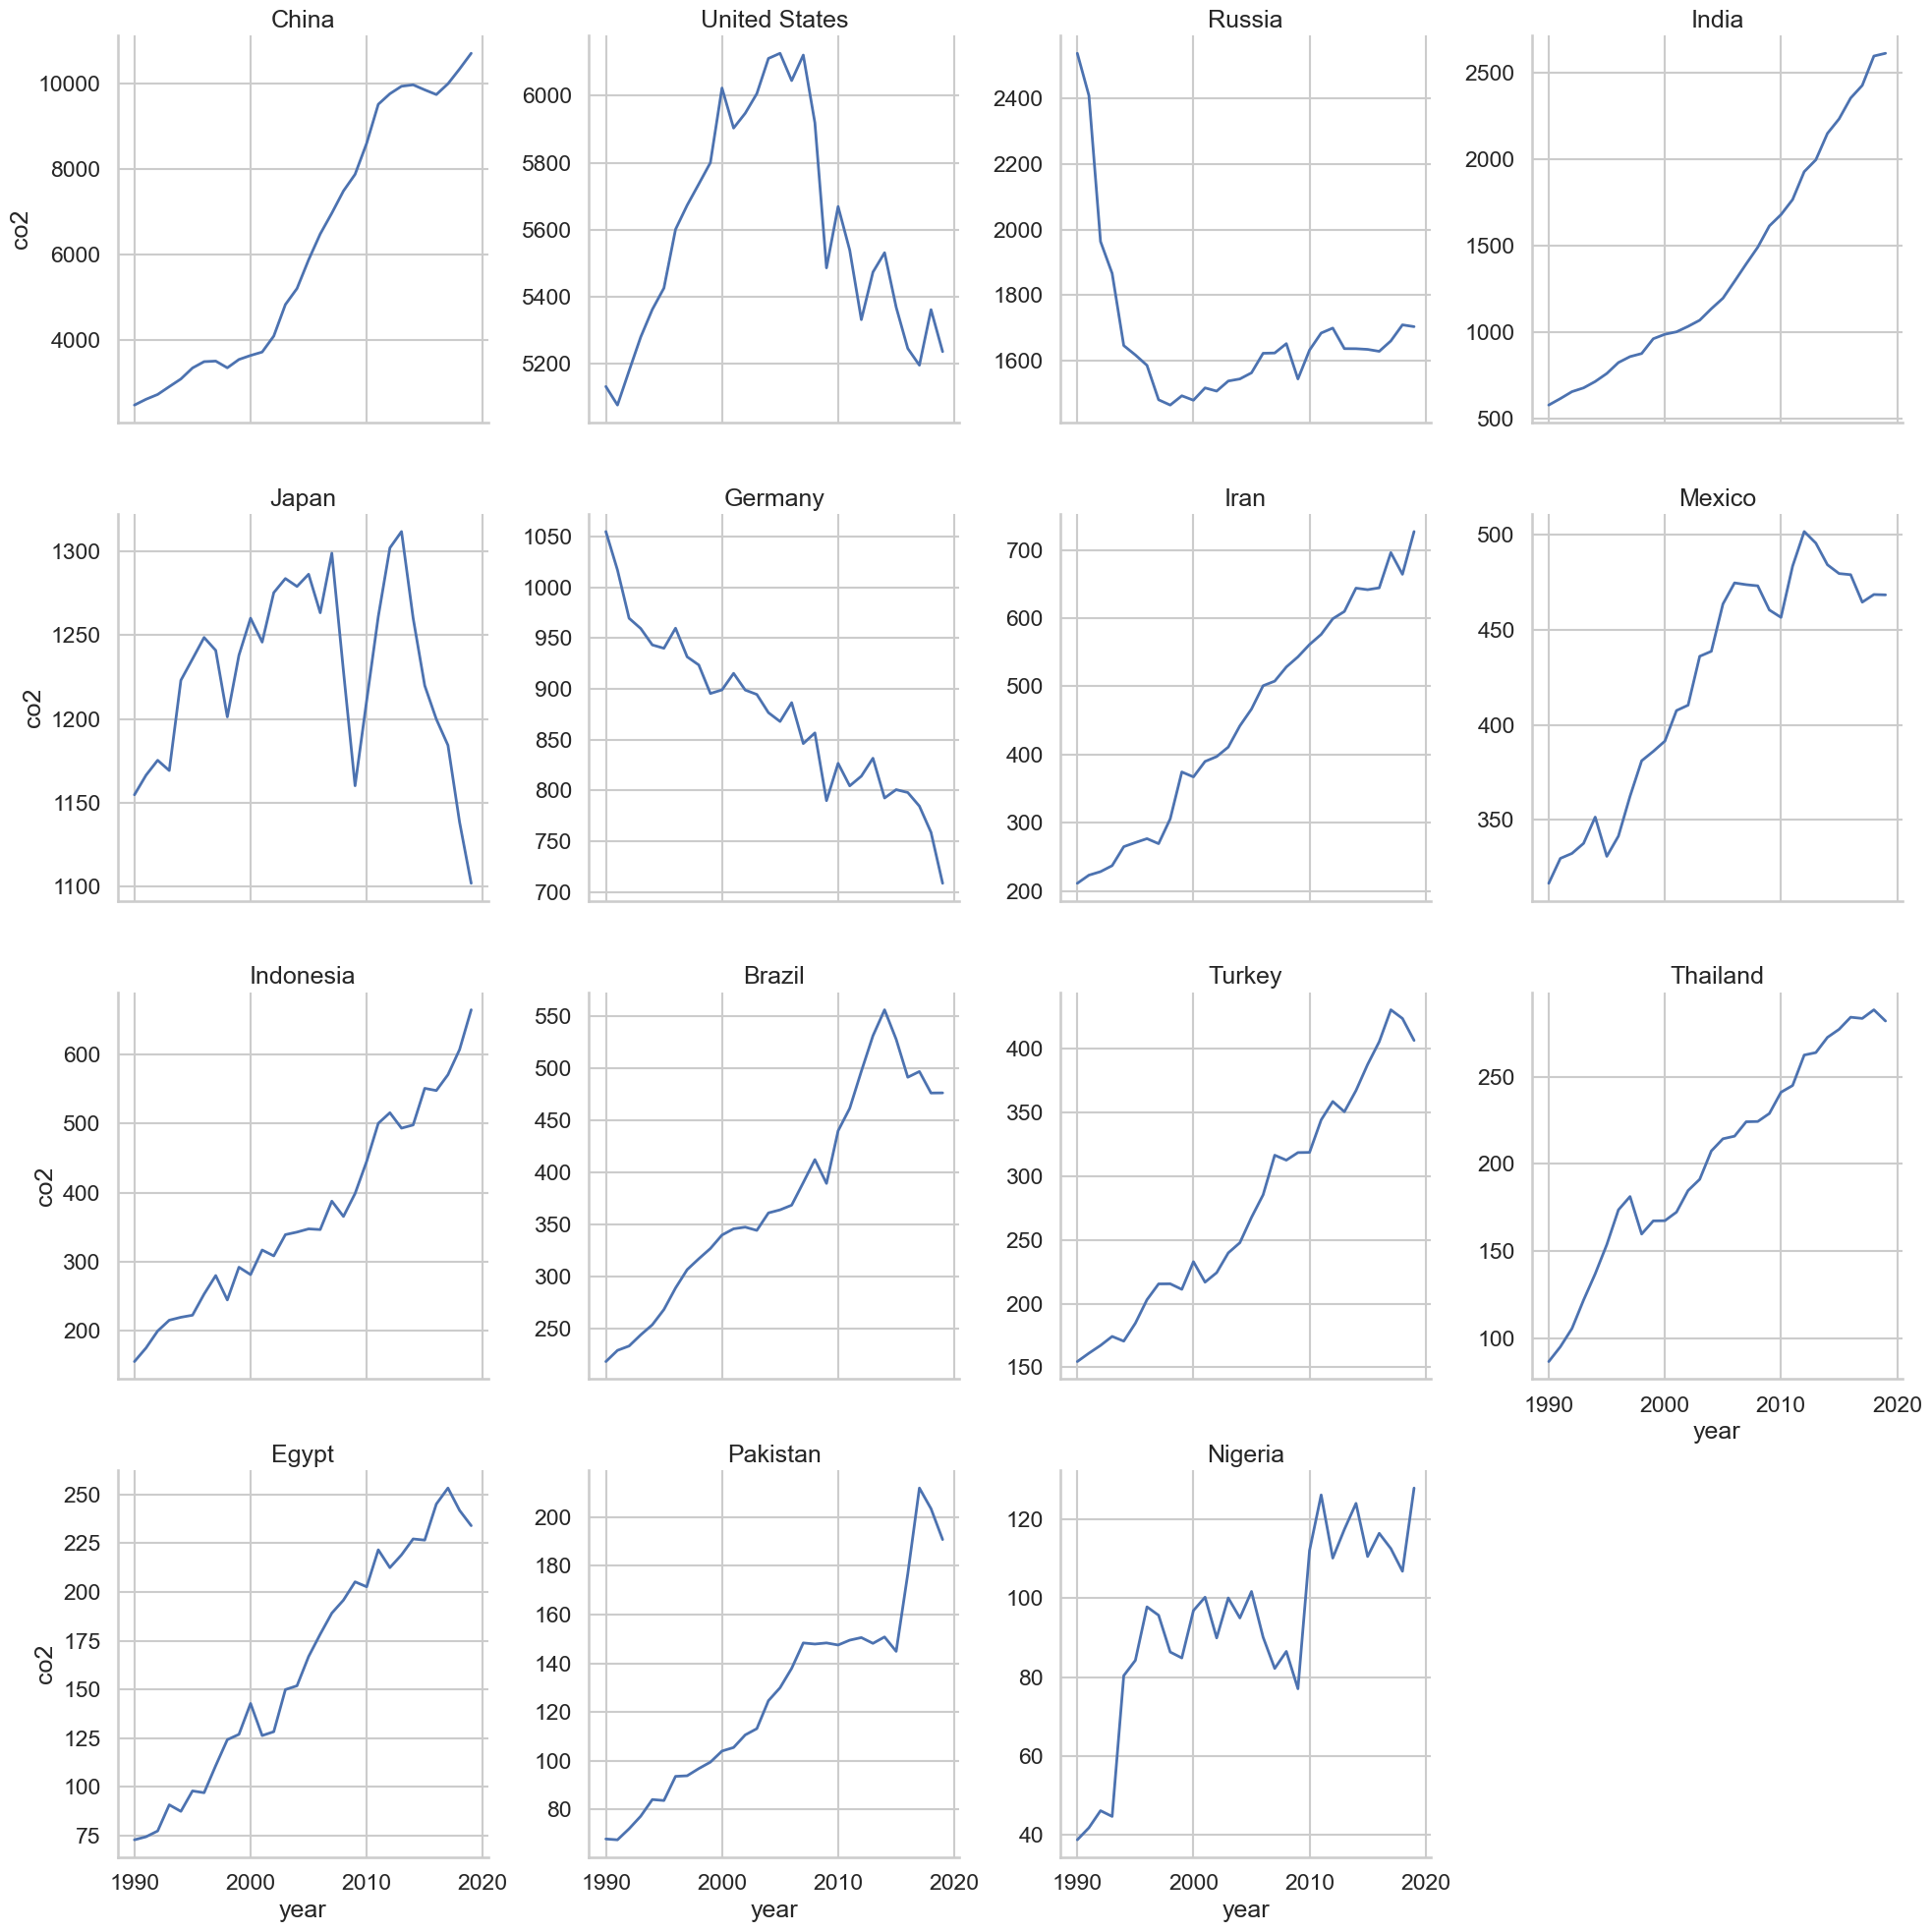

In [28]:
co2_high_low_data = co2_data[co2_data['country'].isin(high_low_co2_emitters.index)]
g=sns.FacetGrid(co2_high_low_data, col='country', col_order=high_low_co2_emitters.index,col_wrap=4, height=5, sharey=False)
g.map_dataframe(sns.lineplot, x='year', y='co2', linewidth=2)
g.set_axis_labels(x='Year', y='CO2 Emissions (Million Tonnes)')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

It looks like countries with developing economies show an upward trend while countries with more mature/developed economies show a downward trend atleast in the past decade which make sense since developing economies have rapid industrialization and hence increased co2 emissions while developed economies have focussed more on energy efficiency and green projects.

Next, Let's identify countries that have the fastest growth in CO2 emissions.

In [29]:
#Identify countries with fastest growth rate in CO2 emissions
co2_filtered=co2_data[co2_data['co2']>5] #establishing a CO2 emissions threshold to avoid small countries showing up for largest changes
co2_data_sorted = co2_filtered.sort_values(['country','year'])
country_co2_growth = co2_data_sorted.groupby('country')['co2'].apply(lambda x: (x.iloc[-1]/x.iloc[0])-1 if len(x)>1 else None).sort_values(ascending=False)
country_co2_growth.head(10)

country
Vietnam       14.930889
Qatar          7.875569
Bangladesh     5.732566
Oman           5.383252
Myanmar        5.339242
Malaysia       4.116604
Mongolia       3.812481
India          3.517705
Angola         3.363458
China          3.313819
Name: co2, dtype: float64

We can see from the results above that top countries for absolute total CO2 emissions are not same as the ones that have fastest growth rate for CO2 emissions. These countries like Vietnam. Bangladesh, Malaysia etc. are becoming more and more industrialized and hence they have a faster growth rate of CO2 emissions compared to industrialized countries like United States, UK, Germany where growth rate has stabilized over time or emissions are so high that year over year percent growth is not as high as rapidly industrializing economies. 

#### 3.5.2.4 Decoupling Analysis<a id='3.5.2.3_Trends_Analysis'></a>

It is important for us to understand if economic growth is becoming more or less carbon intensive. We already know that at global level, although co2 per gdp is seeing a downward trend, the total CO2 emissions still continue to trend upward. This may be due to the fact that although energy efficiency improvements have been done, they are not enough to offset the scale of economic growth and industrialization and also because gdp at global level is not as tightly correlated with co2 emissions. 

We will define a decoupling ratio as co2 growth/gdp growth. A value of >1 shows that co2 is growing faster than gdp, between 0-1 means there is relative decoupling while <0 means absolute decoupling i.e co2 emissions are not being impacted by economic growth.

In [30]:
#calculate decoupling ratio for all countries
co2_data=co2_data.sort_values(['country','year'])
co2_data['co2_growth_rate'] = co2_data.groupby('country')['co2'].pct_change(fill_method=None)
co2_data['gdp_growth_rate'] = co2_data.groupby('country')['gdp'].pct_change(fill_method=None)
co2_data['decoupling_ratio'] = co2_data['co2_growth_rate']/co2_data['gdp_growth_rate']

#remove NaN values
co2_data_clean = co2_data.dropna(subset=['decoupling_ratio'])

#country level decoupling
country_decoupling = co2_data_clean.groupby('country')['decoupling_ratio'].median().sort_values(ascending=False)
country_decoupling.head(10)

country
Nepal          2.443830
Mali           2.037652
Benin          1.939201
North Korea    1.929537
Comoros        1.854417
Senegal        1.782025
Yemen          1.629267
Vietnam        1.590757
Guatemala      1.489366
Haiti          1.435903
Name: decoupling_ratio, dtype: float64

In [31]:
#countries witth absolute decoupling between CO2 emissions and GDP growth
country_decoupling = co2_data_clean.groupby('country')['decoupling_ratio'].median().sort_values()
country_decoupling.head(10)

country
Denmark           -1.313296
United Kingdom    -0.563936
Germany           -0.531241
Mozambique        -0.487288
Cote d'Ivoire     -0.397386
North Macedonia   -0.211247
Finland           -0.180320
Congo             -0.148066
Switzerland       -0.110282
Cameroon          -0.076678
Name: decoupling_ratio, dtype: float64

We see many developed countries on this list with true decoupling due to their energy efficiency policies.

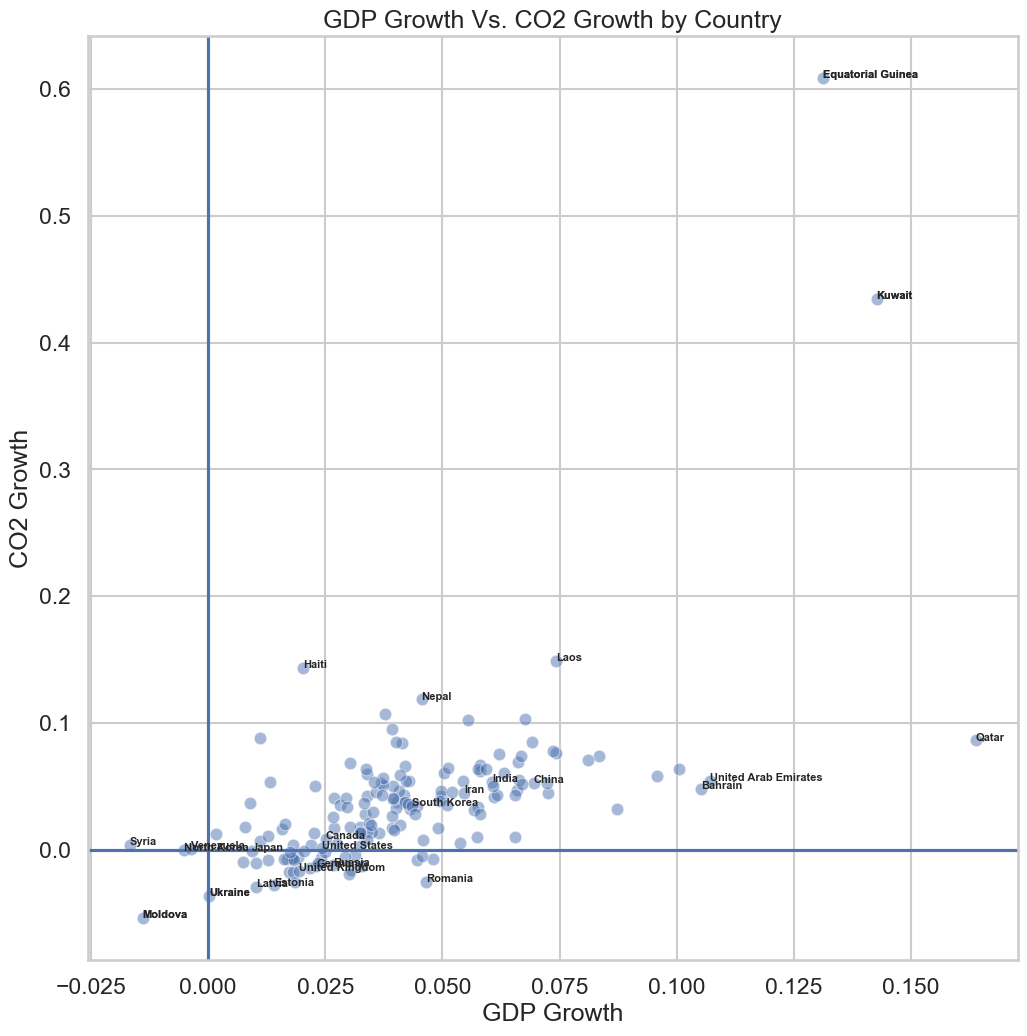

In [32]:
#let us visualize the scatter plot for co2_growth vs. gdp growth
country_growth = co2_data.groupby('country')[['gdp_growth_rate', 'co2_growth_rate', 'co2']].mean().dropna()
high_emitters = country_growth.sort_values('co2', ascending = False).head(10)
high_gdp_growth = country_growth.sort_values('gdp_growth_rate', ascending = False).head(5)
high_co2_growth = country_growth.sort_values('co2_growth_rate', ascending = False).head(5)
low_gdp_growth = country_growth.sort_values('gdp_growth_rate').head(5)
low_co2_growth = country_growth.sort_values('co2_growth_rate').head(5)
plt.figure(figsize = (12,12))
sns.scatterplot(data=country_growth, x='gdp_growth_rate', y='co2_growth_rate', alpha=0.5)

#Adding Labels to our plot for top emitters
for country, row in high_emitters.iterrows():
    plt.text(row['gdp_growth_rate'], row['co2_growth_rate'], country, fontsize=8, fontweight = 'bold')
#Adding Labels to our plot for top gdp growth countries
for country, row in high_gdp_growth.iterrows():
    plt.text(row['gdp_growth_rate'], row['co2_growth_rate'], country, fontsize=8, fontweight = 'bold')
#Adding Labels to our plot for top co2 growth countries
for country, row in high_co2_growth.iterrows():
    plt.text(row['gdp_growth_rate'], row['co2_growth_rate'], country, fontsize=8, fontweight = 'bold')
#Adding Labels to our plot for lowest gdp growth countries
for country, row in low_gdp_growth.iterrows():
    plt.text(row['gdp_growth_rate'], row['co2_growth_rate'], country, fontsize=8, fontweight = 'bold')
#Adding Labels to our plot for lowest co2 growth countries
for country, row in low_co2_growth.iterrows():
    plt.text(row['gdp_growth_rate'], row['co2_growth_rate'], country, fontsize=8, fontweight = 'bold')
plt.axhline(0)
plt.axvline(0)
plt.title("GDP Growth Vs. CO2 Growth by Country")
plt.xlabel("GDP Growth")
plt.ylabel("CO2 Growth")
plt.show()

In the above plot, 
Lower left quandrant represents countries where CO2 growth and GDP growth are both negative.  

Top left quadrant represents countries where CO2 growth is higher than GDP growth. Syria where there has been structural disruption appears here.

Lower right quadrant represents countries where there is absolute decoupling between CO2 growth and GDP growth, i.e. despite GDP growth CO2 growth is negative. Developed Economies like United Kingdom, Germany show this trend. However, not all countries are developed and have absolute decoupling. They appear here as observed previously in the list due to small economy size and hence volatility in this ratio or economic disruptions like for Ukraine.

Upper right quadrant represents countries where CO2 growth relatively coupled GDP growth ie. both CO2 emission and GDP are growing. Developing Economies like India, China, South Korea with strong economic growth show a tight relationship with CO2 emissions.

#### 3.5.2.4 Feature Relationships<a id='3.5.2.3_Feature_Relationships'></a>

Feature relationships show us features interact with each other and also our target variable co2 emissions. It is important to explore these relationships to understand the drivers of economic growth and co2 emissions.

Let us start with a heatmap/correlation matrix to see how our core features of gdp, population, energy_per_capita and co2 relate to each other.

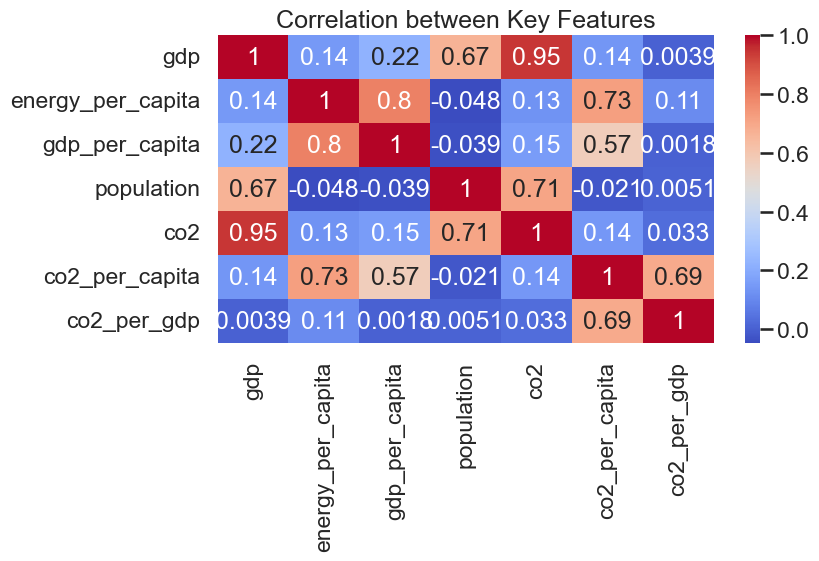

In [33]:
#heatmap for core features
co2_data['gdp_per_capita']=co2_data['gdp']/co2_data['population']
corr_matrix=co2_data[['gdp','energy_per_capita','gdp_per_capita','population','co2', 'co2_per_capita', 'co2_per_gdp']].corr()
plt.figure(figsize=(8,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between Key Features")
plt.show()

We see a very high correlation of 0.95 between gdp and CO2 emissions at national level which makes sense since economic growth can lead to high CO2 emissions in many developing nations. We also see a moderately high correlation between co2_per_capita and energy_per_capita which again makes sence since higher energy per consumption is tightly linked to co2 emissions are previously observed for many nations. We also see a moderately high correlation between total co2 emissions and population which again makes sence since higher population especially in developing nations can lead to higher co2 emissions.

We will zoom in further on the relationship between energy_per_capita, gdp_per_capita and co2_per_capita.

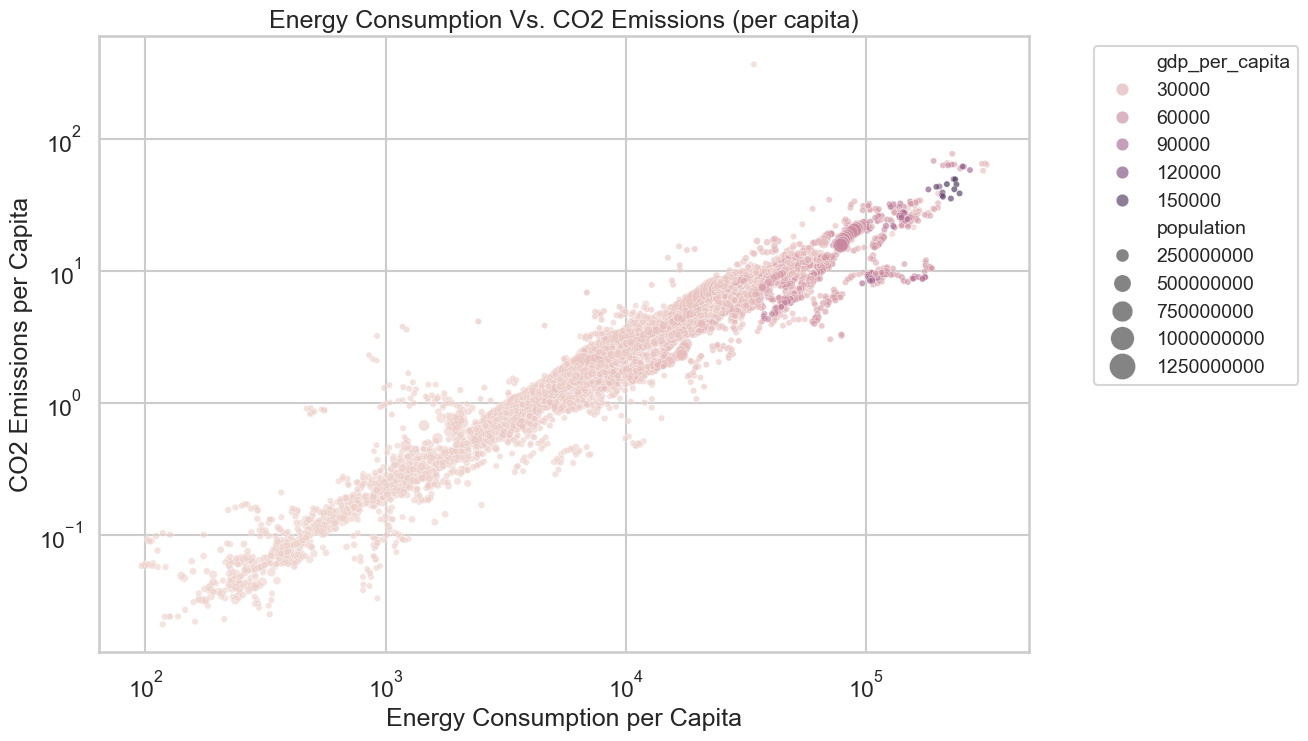

In [34]:
#first create gdp per capita column
co2_data['gdp_per_capita']=co2_data['gdp']/co2_data['population']
plt.figure(figsize=(12,8))
sns.scatterplot(co2_data,x='energy_per_capita',y='co2_per_capita', size='population', hue='gdp_per_capita', alpha=0.6, sizes=(20,400))
plt.xscale('log')
plt.yscale('log')
plt.title("Energy Consumption Vs. CO2 Emissions (per capita)")
plt.xlabel("Energy Consumption per Capita")
plt.ylabel("CO2 Emissions per Capita")
plt.legend(bbox_to_anchor=(1.3,1), prop={'size': 14})
plt.show()

From the multidimensional scatter plot between energy per capita, co2 per capita and gdp per capita, we see a stong relationship of energy consumption per capita with co2 emissions per capita indicating that energy consumption is a important driver of co2 emissions. We also see that higher income (gdp per capita) countries are most concentrated on the top right indicating that economic development also results in higher energy demand and hence higher co2 emissions compared to lower income(gdp per capita) countries in milder magenta color at the lower left.

Lastly, let us also zoom into the relationship between population and co2 emissions.

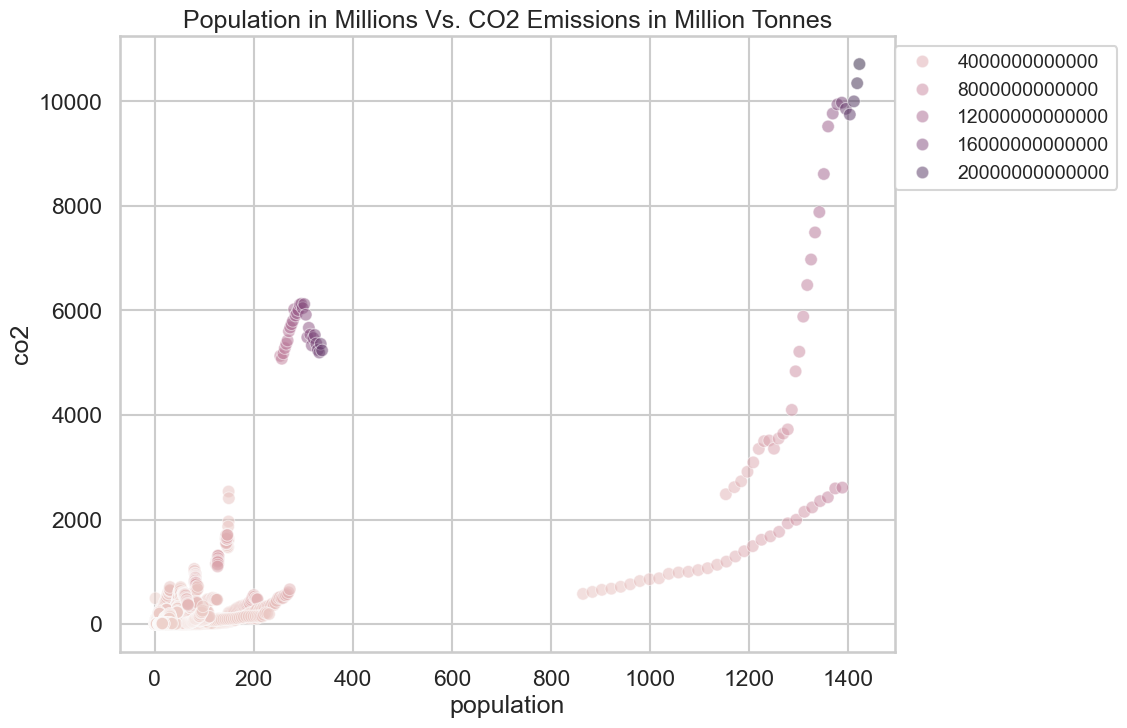

In [35]:
#scatterplot for population vs. co2 emissions
co2_data_population = co2_data.copy()
co2_data_population['population']=co2_data_population['population']/1000000
plt.figure(figsize=(10,8))
sns.scatterplot(co2_data_population, x='population',y='co2',hue='gdp',alpha=0.5)
plt.title("Population in Millions Vs. CO2 Emissions in Million Tonnes")
plt.legend(bbox_to_anchor=(1.3,1), prop={'size': 14})
plt.show()

We can see for most part that highly populated countries especially with strong economies tend to have higher CO2 emissions while smaller countries with lower population and lower gdp tend to have lower CO2 emissions. So, we do see a moderately strong positive relationship between population and co2 emissions.

#### 3.5.2.5 Multicollinearity Check<a id='3.5.2.3_Multicollinearity_Check'></a>

We will use Variance Inflation Factor (VIF) statistical test similar to the check we did on global co2 plastics dataset for multicollinearity.

In [36]:
#vif check for multicollinearity on core predictor features in co2 dataset
fcols = ['gdp', 'energy_per_capita', 'population', 'co2_per_capita']

vif = co2_data[fcols].dropna()

co2_data_vif = pd.DataFrame()
co2_data_vif["feature"] = vif.columns
co2_data_vif["VIF"] = [variance_inflation_factor(vif.values, i)
                   for i in range(len(vif.columns))]

co2_data_vif

,feature,VIF
0,gdp,2.080148
1,energy_per_capita,1.908131
2,population,1.798746
3,co2_per_capita,2.095508


All VIF values are below 5 meaning we do not see moderate or sever multicollinearity. We will model for both co2 and co2_per_capita with different feature sets (with and without population). Let us calculate VIF for both set of features and look at the values again.

In [37]:
#Recalculating VIF without derived features
#vif check for multicollinearity on core predictor features in co2 dataset
fcols = ['gdp', 'energy_per_capita', 'population']

vif = co2_data[fcols].dropna()

vif = sm.add_constant(vif)

co2_data_vif = pd.DataFrame()
co2_data_vif["feature"] = vif.columns[1:]
co2_data_vif["VIF"] = [variance_inflation_factor(vif.values, i)
                   for i in range(1,len(vif.columns))]

co2_data_vif = co2_data_vif[co2_data_vif["feature"] != "const"]

co2_data_vif

,feature,VIF
0,gdp,1.911213
1,energy_per_capita,1.062237
2,population,1.875509


energy_per_capita VIF value dropped quite a bit from 1.9 to 0.73 for co2 as target. Let us check out the VIF for features to predict co2_per_capita.

In [38]:
#Recalculating VIF for co2_per_capita as our target variable
#vif check for multicollinearity on core predictor features in co2 dataset
fcols = ['gdp_per_capita', 'energy_per_capita']

vif = co2_data[fcols].dropna()

vif = sm.add_constant(vif)

co2_data_vif = pd.DataFrame()
co2_data_vif["feature"] = vif.columns[1:]
co2_data_vif["VIF"] = [variance_inflation_factor(vif.values, i)
                   for i in range(1,len(vif.columns))]

co2_data_vif = co2_data_vif[co2_data_vif["feature"] != "const"]

co2_data_vif

,feature,VIF
0,gdp_per_capita,2.743235
1,energy_per_capita,2.743235


Both feature sets have acceptable values of VIF.

Next, we will do some checks and create a model ready dataset.

#### 3.5.2.5 Model Readiness Checks<a id='3.5.2.5_Model_Readiness_Checks'></a>

In this final section, we will assess the co2 master dataset at country/year level again to make sure it is ready for modeling.

In [39]:
#Lets once again check missing data and either impute it or drop the rows
co2_data[['co2','gdp','population','energy_per_capita','co2_per_capita']].isnull().sum()

co2                   1
gdp                   2
population            0
energy_per_capita    51
co2_per_capita        1
dtype: int64

In [40]:
#Lets inspect the missing feature rows and then perform the needed data set updates
co2_data[co2_data['co2'].isnull()]

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp,co2_growth_rate,gdp_growth_rate,decoupling_ratio,gdp_per_capita
3090,Namibia,1990,NAM,1369309.0,7.363139e+09,NaN,NaN,NaN,7418.709,1.38,NaN,NaN,NaN,5377.266074


In [41]:
#we will use backward fill to get data for this one year for Namibia for both co2 and co2_per_capita
co2_data['co2'] = co2_data.groupby('country')['co2'].transform(lambda x: x.interpolate().bfill())
co2_data['co2_per_capita'] = co2_data.groupby('country')['co2_per_capita'].transform(lambda x: x.interpolate().bfill())

In [42]:
#lets check for co2 missing values again
co2_data[co2_data['co2'].isnull()]
co2_data[co2_data['co2_per_capita'].isnull()]

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp,co2_growth_rate,gdp_growth_rate,decoupling_ratio,gdp_per_capita


Great! Let us do the same for gdp as well since it is missing only 2 values.

In [43]:
#we will use backward fill to get data for 2 beginning years of United Arab Emirates
co2_data['gdp'] = co2_data.groupby('country')['gdp'].transform(lambda x: x.interpolate().bfill())

In [44]:
#lets check for gdp missing values again
co2_data[co2_data['gdp'].isnull()]

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp,co2_growth_rate,gdp_growth_rate,decoupling_ratio,gdp_per_capita


energy_per_capita is missing quite a few rows(51). Let us inspect it and decide on next steps

In [45]:
co2_data[co2_data['energy_per_capita'].isnull()]

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp,co2_growth_rate,gdp_growth_rate,decoupling_ratio,gdp_per_capita
150,Armenia,1990,ARM,3552130.0,3.265011e+10,9.003,2.535,0.276,NaN,NaN,NaN,NaN,NaN,9191.700312
151,Armenia,1991,ARM,3613978.0,2.795980e+10,7.383,2.043,0.264,NaN,NaN,-0.179940,-0.143654,1.252594,7736.571672
480,Bosnia and Herzegovina,1990,BIH,4448658.0,2.606855e+10,19.872,4.467,0.762,NaN,NaN,NaN,NaN,NaN,5859.867370
481,Bosnia and Herzegovina,1991,BIH,4458350.0,2.275946e+10,14.060,3.154,0.618,NaN,NaN,-0.292472,-0.126938,2.304057,5104.907301
1650,Georgia,1990,GEO,5448865.0,6.587415e+10,14.850,2.725,0.225,NaN,NaN,NaN,NaN,NaN,12089.518342
1651,Georgia,1991,GEO,5379509.0,5.173242e+10,14.602,2.714,0.282,NaN,NaN,-0.016700,-0.214678,0.077792,9616.568726
2400,Kyrgyzstan,1990,KGZ,4459545.0,2.516423e+10,19.204,4.306,0.763,NaN,NaN,NaN,NaN,NaN,5642.780529
2401,Kyrgyzstan,1991,KGZ,4532124.0,2.294828e+10,15.897,3.508,0.693,NaN,NaN,-0.172204,-0.088060,1.955534,5063.471110
2910,Moldova,1990,MDA,4451150.0,4.321499e+10,36.505,8.201,0.845,NaN,NaN,NaN,NaN,NaN,9708.724712
2911,Moldova,1991,MDA,4456609.0,3.501836e+10,29.618,6.646,0.846,NaN,NaN,-0.188659,-0.189671,0.994665,7857.625334


In [46]:
#Since Montenegro and Serbia are missing 16 years of energy per capita data, we will drop these two countries altogether
co2_data = co2_data[~co2_data['country'].isin(['Serbia','Montenegro'])]
#Since Palestine is missing energy_per_capita data for the initial 7 years, we will go ahead and drop those years since it will be difficult to impute this data
co2_data=co2_data[~((co2_data['country'] == 'Palestine') & (co2_data['year'] < 1997))]
#Since remaining countries are missing energy per capita data for 1990 and 1991 only we will backfill that data
#we will use backward fill to get data for 2 beginning years of United Arab Emirates
co2_data['energy_per_capita'] = co2_data.groupby('country')['energy_per_capita'].transform(lambda x: x.interpolate().bfill())

In [47]:
#lets check if it resolved missing values for energy_per_capita and for the entire dataset
co2_data[co2_data['energy_per_capita'].isnull()]
co2_data[['co2','gdp','population','energy_per_capita', 'co2_per_capita']].isnull().sum()

co2                  0
gdp                  0
population           0
energy_per_capita    0
co2_per_capita       0
dtype: int64

Great! We do not have missing data now.

We previously saw that our core features of gdp, population, energy per capita and co2 all were right skewed. The degree of skewness varied with gdp and co2 being extremely right skewed. Let us do a log transform on this features and then quickly check the correlations, features and multicollinearity to see if we can use log transformations of these features for modeling.

In [48]:
#creating columns with log transforms on core features for modeling
co2_data['log_energy_per_capita']=np.log(co2_data['energy_per_capita'])
co2_data['log_energy']=np.log(co2_data['energy_per_capita']*co2_data['population'])
co2_data['log_gdp']=np.log(co2_data['gdp'])
co2_data['log_population']=np.log(co2_data['population'])
co2_data['log_co2']=np.log(co2_data['co2'])
co2_data['log_co2_per_capita']=np.log(co2_data['co2_per_capita'])
co2_data['log_gdp_per_capita']=np.log(co2_data['gdp']/co2_data['population'])

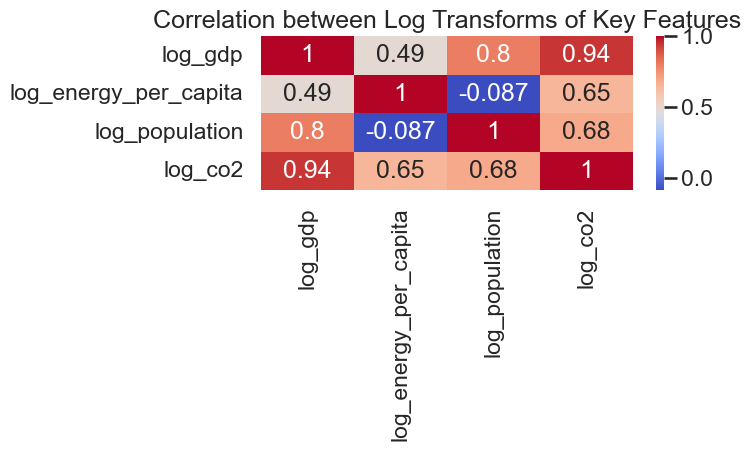

In [49]:
#quick correlations check for 1st feature set (to model co2 emissions)
#heatmap for core features
corr_matrix_log=co2_data[['log_gdp','log_energy_per_capita','log_population','log_co2']].corr()
plt.figure(figsize=(6,2))
sns.heatmap(corr_matrix_log, annot=True, cmap='coolwarm')
plt.title("Correlation between Log Transforms of Key Features")
plt.show()

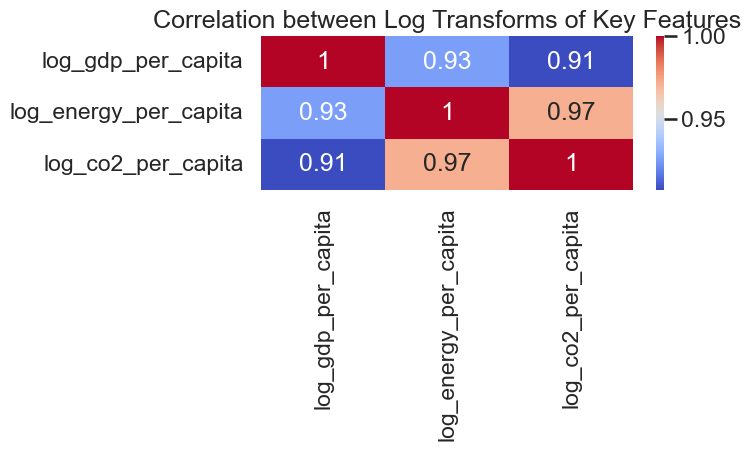

In [50]:
#quick correlations check for 2nd feature set (to model co2 per capita emissions)
#heatmap for core features
corr_matrix_log=co2_data[['log_gdp_per_capita','log_energy_per_capita','log_co2_per_capita']].corr()
plt.figure(figsize=(6,2))
sns.heatmap(corr_matrix_log, annot=True, cmap='coolwarm')
plt.title("Correlation between Log Transforms of Key Features")
plt.show()

We do see some strong correlations for both these feature sets especially between log_gdp_per_capita, log_energy_per_capita and log_co2_per_capita. 

Let us also do a multicollinearity check for both feature sets.

In [51]:
#vif check for multicollinearity on core predictor features in co2 dataset
fcols = ['log_gdp', 'log_energy_per_capita', 'log_population']

vif_log = co2_data[fcols].dropna()

vif_log = sm.add_constant(vif_log)

co2_data_vif_log = pd.DataFrame()
co2_data_vif_log["feature"] = vif_log.columns
co2_data_vif_log["VIF"] = [variance_inflation_factor(vif_log.values, i)
                   for i in range(len(vif_log.columns))]

co2_data_vif_log

,feature,VIF
0,const,161.707294
1,log_gdp,19.250248
2,log_energy_per_capita,7.051082
3,log_population,14.807050


We see VIF higher than 10 for log_gdp and log_population which is unacceptable. To avoid this gdp population identity problem, let us try another gdp feature, gdp_per_capita instead of gdp and look at the VIF.

In [52]:
#vif check for multicollinearity on core predictor features of log co2 in co2 dataset
fcols = ['log_gdp_per_capita', 'log_energy_per_capita','log_population']

vif_log = co2_data[fcols].dropna()

vif_log = sm.add_constant(vif_log)

co2_data_vif_log = pd.DataFrame()
co2_data_vif_log["feature"] = vif_log.columns
co2_data_vif_log["VIF"] = [variance_inflation_factor(vif_log.values, i)
                   for i in range(len(vif_log.columns))]

co2_data_vif_log

,feature,VIF
0,const,161.707294
1,log_gdp_per_capita,7.016460
2,log_energy_per_capita,7.051082
3,log_population,1.013523


In [53]:
#vif check for multicollinearity on core predictor features of log co2 per capita in co2 dataset
fcols = ['log_gdp_per_capita', 'log_energy_per_capita']

vif_log = co2_data[fcols].dropna()

vif_log = sm.add_constant(vif_log)

co2_data_vif_log = pd.DataFrame()
co2_data_vif_log["feature"] = vif_log.columns
co2_data_vif_log["VIF"] = [variance_inflation_factor(vif_log.values, i)
                   for i in range(len(vif_log.columns))]

co2_data_vif_log

,feature,VIF
0,const,69.658382
1,log_gdp_per_capita,6.975880
2,log_energy_per_capita,6.975880


This looks much better and acceptable given that VIF values are <10 indicating low to moderate multicollinearity.

Let us do a quick correlation matrix on this features set of log_co2, log_gdp_per_capita, log_energy_per_capita and log_population to check if these can be our final predictor variables dataset for modeling.

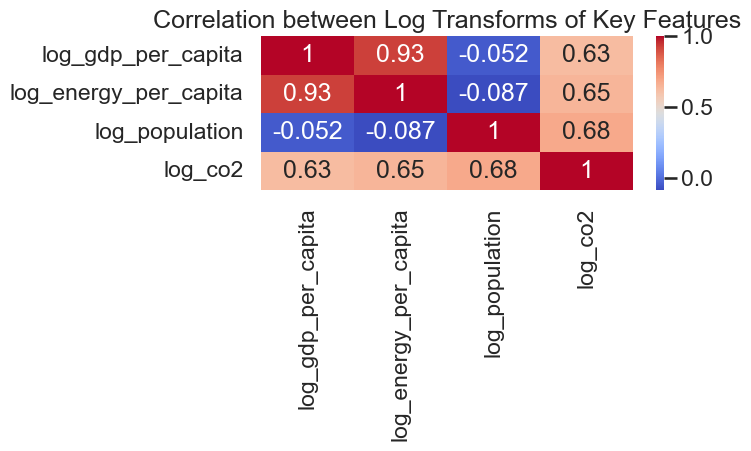

In [54]:
#quick correlations check
#heatmap for core features
corr_matrix_log=co2_data[['log_gdp_per_capita','log_energy_per_capita','log_population','log_co2']].corr()
plt.figure(figsize=(6,2))
sns.heatmap(corr_matrix_log, annot=True, cmap='coolwarm')
plt.title("Correlation between Log Transforms of Key Features")
plt.show()

The correlation values are also acceptable. Next, let us take a quick look at the distributions for these log features to make sure they are not very skewed.

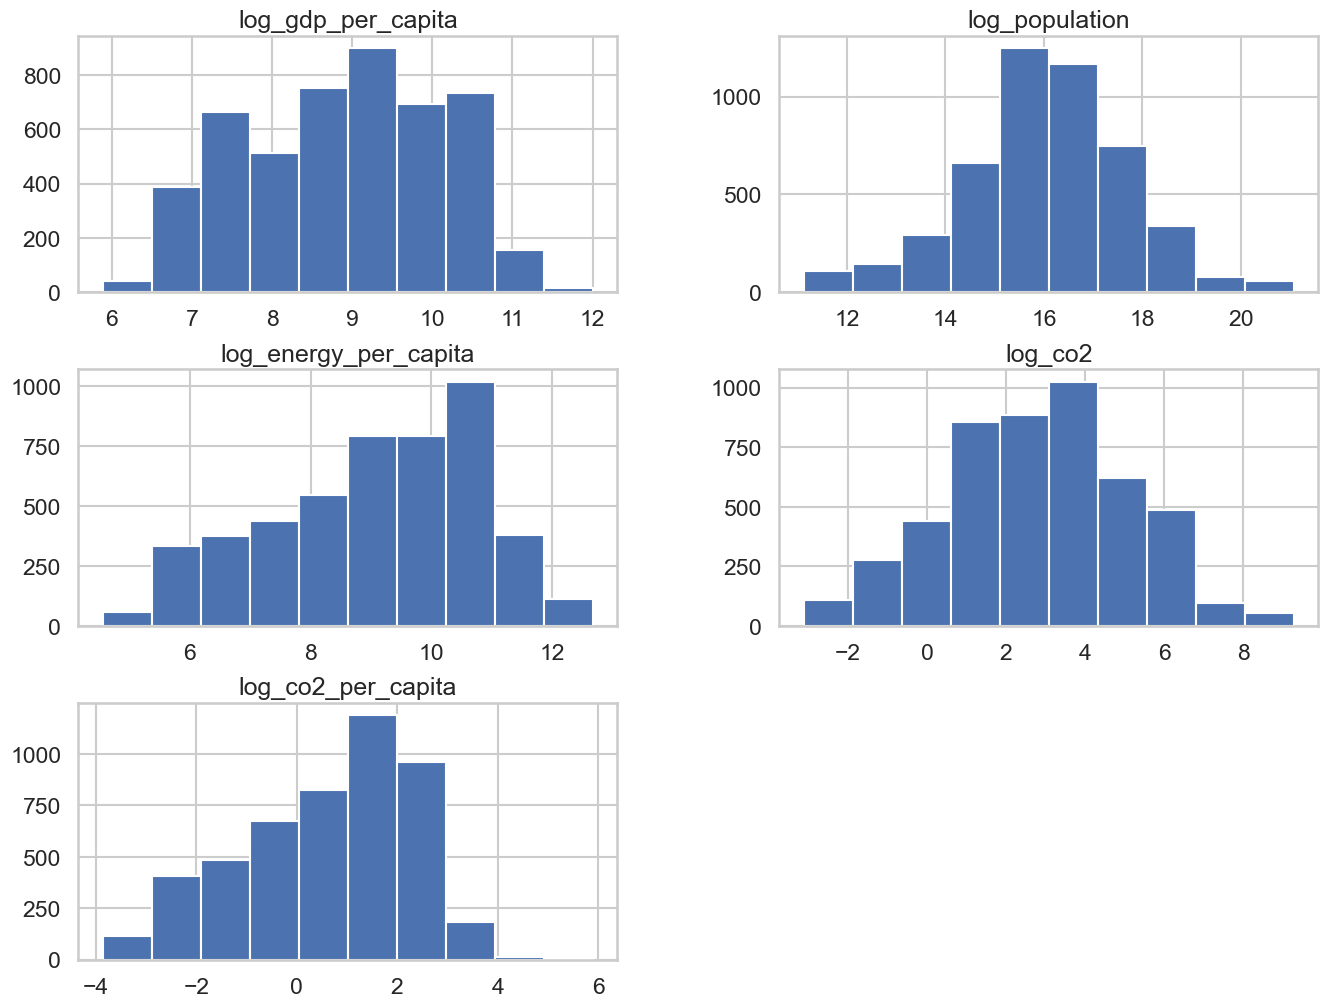

In [55]:
_=co2_data[['log_gdp_per_capita','log_population','log_energy_per_capita','log_co2', 'log_co2_per_capita']].hist(figsize=(16,12))

The distributions look much more sysmmetrical and skewness have been reduced drastically. We will finalize these as our core features for modeling and create a model ready dataset next.

In [56]:
model_data = co2_data[['country','year','iso_code','log_co2', 'log_gdp_per_capita', 'log_energy_per_capita', 'log_population', 'log_co2_per_capita']]
model_data.head()

,country,year,iso_code,log_co2,log_gdp_per_capita,log_energy_per_capita,log_population,log_co2_per_capita
0,Afghanistan,1990,AFG,0.705076,6.989063,7.826789,16.304215,-1.783791
1,Afghanistan,1991,AFG,0.649195,6.891983,6.928611,16.320128,-1.857899
2,Afghanistan,1992,AFG,0.393393,6.861405,6.426577,16.401693,-2.189256
3,Afghanistan,1993,AFG,0.396761,6.489406,6.302176,16.519765,-2.302585
4,Afghanistan,1994,AFG,0.374318,6.188986,6.182800,16.603653,-2.419119


In [57]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4853 entries, 0 to 4919
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                4853 non-null   object 
 1   year                   4853 non-null   int64  
 2   iso_code               4853 non-null   object 
 3   log_co2                4853 non-null   float64
 4   log_gdp_per_capita     4853 non-null   float64
 5   log_energy_per_capita  4853 non-null   float64
 6   log_population         4853 non-null   float64
 7   log_co2_per_capita     4853 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 341.2+ KB


In [58]:
# save model data to a new csv file
datapath = '../data/processed'
save_file(model_data, 'model_ready_data.csv', datapath)

A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../data/processed\model_ready_data.csv"


In [59]:
#save global co2 plastics normalized data as well for establishing a connection between plastics production and co2 emissions later
datapath = '../data/processed'
save_file(global_co2_plastics_norm, 'global_co2_plastics_norm.csv', datapath)

Writing file.  "../data/processed\global_co2_plastics_norm.csv"


## 3.6 Summary<a id='3.6_Summary'></a>

**1. For our Global CO2 Plastics Dataset at global year level (1990-2019), we have the following key takeways**<p>
**a.** All core features, gdp, energy use per capita, plastics production and population have been growing consistently for our study period of 1990-2019.<p>
**b.** CO2 emissions per unit GDP and Energy per Capita use per unit GDP have seen an opposite downward trend indicating energy efficiency improvements. These gains have not been sufficient to offset the CO2 emissions trend that still continues to rise globally.<p>
**c.** Energy use per capita seems to have the strongest relationship with CO2 emissions, meaning increased energy use leads to increased CO2 emissions.<p>
**d.** There is strong multicollinearity among all the core features in this global dataset of limited size (only 30 rows) making it difficult to use this for modeling and drawing causal inference based on this data.<p>

**2. For our CO2 master dataset at country year level (1990-2019), we have the following key takeaways**<p>
**a.** Countries with larger population and higher gdp are closely related to greater CO2 emissions.<p>
**b.**	Energy Consumption Per Capita also seems to have a strong positive correlation with CO2 emissions suggesting its key role in global warming.<p>
**c.**	We also see that developed economies show decoupling between economic growth (gdp) and co2 emissions suggesting CO2 emissions stabilize or decline over time due to potential energy efficiency and green projects.<p>
**d.**	All feature distributions (gdp, gdp_per_capita, population, energy per capita and co2, co2_per_capita) are right skewed with skewness varying in severity. Hence, we decided to use log transformation of these features for modeling as the distributions looked more symmetrical while still being correlated and multicollinearity is not severe. They also provide more acceptable statistical properties for regression modeling.<p>